In [2]:
#import libraries used to calculating statistical insights and creating plotes
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load data
dataset = pd.read_csv(r"drug_regulatory_classification_dataset.csv")
dataset.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [4]:
#convert yes/no to binary
binary_cols = ["Requires_Cold_Storage", "OTC_Flag", "High_Risk_Substance"]

for col in binary_cols:
    dataset[col] = dataset[col].map({"Yes":1, "No":0})

In [5]:
#seperate numerical column
num_cols = dataset.select_dtypes(exclude=["object"]).columns
cat_cols = dataset.select_dtypes(include=["object"]).columns

In [6]:
num_cols

Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage',
       'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance',
       'Insurance_Coverage_Percentage', 'Export_Percentage',
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')

In [7]:
cat_cols

Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Target_Regulatory_Class'],
      dtype='object')

In [8]:
dataset.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,0,0,0,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,1,1,0,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,1,1,0,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,0,1,0,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,0,1,0,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [9]:
dataset.info

<bound method DataFrame.info of        Dosage_mg  Price_Per_Unit  Production_Cost  Marketing_Spend  \
0            250          364.22           246.49        159132.53   
1            500          112.86            73.22        260595.45   
2            200          197.24           100.72        106818.45   
3            500          373.55           264.76        231304.59   
4            500          353.87           277.29        319403.02   
...          ...             ...              ...              ...   
59995        200          260.68           167.61        337160.40   
59996        200          249.67           139.19        457366.23   
59997        100          155.15            78.35        367705.08   
59998        500           42.46            19.05        259954.00   
59999        250          153.99            83.04        267876.28   

       Clinical_Trial_Phase  Side_Effect_Severity_Score  \
0                         3                        4.26   
1        

In [10]:
dataset.describe

<bound method NDFrame.describe of        Dosage_mg  Price_Per_Unit  Production_Cost  Marketing_Spend  \
0            250          364.22           246.49        159132.53   
1            500          112.86            73.22        260595.45   
2            200          197.24           100.72        106818.45   
3            500          373.55           264.76        231304.59   
4            500          353.87           277.29        319403.02   
...          ...             ...              ...              ...   
59995        200          260.68           167.61        337160.40   
59996        200          249.67           139.19        457366.23   
59997        100          155.15            78.35        367705.08   
59998        500           42.46            19.05        259954.00   
59999        250          153.99            83.04        267876.28   

       Clinical_Trial_Phase  Side_Effect_Severity_Score  \
0                         3                        4.26   
1      

In [21]:
#calculating mean of each column
print("Mean:\n", dataset[num_cols].mean())

Mean:
 Dosage_mg                              292.434167
Price_Per_Unit                         253.312360
Production_Cost                        151.954054
Marketing_Spend                     266968.294472
Clinical_Trial_Phase                     2.502750
Side_Effect_Severity_Score               5.498936
Abuse_Potential_Score                    2.847217
Prescription_Rate                        0.526119
Hospital_Distribution_Percentage        47.411735
Pharmacy_Distribution_Percentage        52.588265
Annual_Sales_Volume                  32212.637060
Regulatory_Risk_Score                    3.907900
Approval_Time_Months                    32.335017
Patent_Duration_Years                    9.986983
R&D_Investment_Million                 100.536433
Competitor_Count                        11.968967
Recall_History_Count                     0.499533
Adverse_Event_Reports                    4.996517
Requires_Cold_Storage                    0.500050
OTC_Flag                                 0.

In [22]:
#calculating median of each column
print("Median:\n", dataset[num_cols].median())

Median:
 Dosage_mg                              250.000
Price_Per_Unit                         252.870
Production_Cost                        146.395
Marketing_Spend                     258385.470
Clinical_Trial_Phase                     3.000
Side_Effect_Severity_Score               5.500
Abuse_Potential_Score                    2.630
Prescription_Rate                        0.530
Hospital_Distribution_Percentage        47.450
Pharmacy_Distribution_Percentage        52.550
Annual_Sales_Volume                  22370.150
Regulatory_Risk_Score                    3.890
Approval_Time_Months                    32.000
Patent_Duration_Years                   10.000
R&D_Investment_Million                 100.750
Competitor_Count                        12.000
Recall_History_Count                     0.000
Adverse_Event_Reports                    5.000
Requires_Cold_Storage                    1.000
OTC_Flag                                 1.000
High_Risk_Substance                      0.000
Insu

In [23]:
#calculating mode of each column
print("Mode:\n", dataset[num_cols].mode())

Mode:
     Dosage_mg  Price_Per_Unit  Production_Cost  Marketing_Spend  \
0       500.0          188.88            47.44         32216.66   
1         NaN          240.80            55.46         46017.46   
2         NaN             NaN            69.76         53233.11   
3         NaN             NaN            77.17         55190.30   
4         NaN             NaN            84.31         73845.98   
5         NaN             NaN           147.76         89963.65   
6         NaN             NaN           159.72        104392.51   
7         NaN             NaN              NaN        121250.00   
8         NaN             NaN              NaN        123142.12   
9         NaN             NaN              NaN        124290.38   
10        NaN             NaN              NaN        160833.85   
11        NaN             NaN              NaN        162576.18   
12        NaN             NaN              NaN        193340.40   
13        NaN             NaN              NaN        2

In [24]:
#calculating variance of each column
print("Variance:\n", dataset[num_cols].var())

Variance:
 Dosage_mg                           4.621465e+04
Price_Per_Unit                      2.043416e+04
Production_Cost                     8.469224e+03
Marketing_Spend                     3.355537e+10
Clinical_Trial_Phase                1.250047e+00
Side_Effect_Severity_Score          6.782787e+00
Abuse_Potential_Score               2.536289e+00
Prescription_Rate                   6.034845e-02
Hospital_Distribution_Percentage    6.016801e+02
Pharmacy_Distribution_Percentage    6.016801e+02
Annual_Sales_Volume                 1.364681e+09
Regulatory_Risk_Score               2.002755e+00
Approval_Time_Months                2.420763e+02
Patent_Duration_Years               2.980881e+01
R&D_Investment_Million              3.287024e+03
Competitor_Count                    5.217697e+01
Recall_History_Count                5.025748e-01
Adverse_Event_Reports               5.000821e+00
Requires_Cold_Storage               2.500042e-01
OTC_Flag                            2.500038e-01
High_Risk

In [25]:
#calculating standard deviation of each column
print("Standard Deviation:\n", dataset[num_cols].std())

Standard Deviation:
 Dosage_mg                              214.975937
Price_Per_Unit                         142.948109
Production_Cost                         92.028388
Marketing_Spend                     183181.235850
Clinical_Trial_Phase                     1.118055
Side_Effect_Severity_Score               2.604378
Abuse_Potential_Score                    1.592573
Prescription_Rate                        0.245659
Hospital_Distribution_Percentage        24.529169
Pharmacy_Distribution_Percentage        24.529169
Annual_Sales_Volume                  36941.588811
Regulatory_Risk_Score                    1.415187
Approval_Time_Months                    15.558802
Patent_Duration_Years                    5.459745
R&D_Investment_Million                  57.332576
Competitor_Count                         7.223363
Recall_History_Count                     0.708925
Adverse_Event_Reports                    2.236252
Requires_Cold_Storage                    0.500004
OTC_Flag                     

In [26]:
#calculating skewness of each column
print("Skewness:\n", dataset[num_cols].skew())

Skewness:
 Dosage_mg                           0.547165
Price_Per_Unit                     -0.003066
Production_Cost                     0.310520
Marketing_Spend                     2.777252
Clinical_Trial_Phase               -0.005063
Side_Effect_Severity_Score         -0.000900
Abuse_Potential_Score               0.604516
Prescription_Rate                  -0.003751
Hospital_Distribution_Percentage    0.005113
Pharmacy_Distribution_Percentage   -0.005113
Annual_Sales_Volume                 6.985907
Regulatory_Risk_Score               0.176532
Approval_Time_Months                0.011615
Patent_Duration_Years               0.003445
R&D_Investment_Million             -0.006125
Competitor_Count                    0.005927
Recall_History_Count                1.409708
Adverse_Event_Reports               0.448501
Requires_Cold_Storage              -0.000200
OTC_Flag                           -0.002533
High_Risk_Substance                 4.708310
Insurance_Coverage_Percentage       0.012320

In [27]:
#calculate kurtosis of each column
print("Kurtosis:\n", dataset[num_cols].kurtosis())

Kurtosis:
 Dosage_mg                            -1.196222
Price_Per_Unit                       -1.201311
Production_Cost                      -0.776065
Marketing_Spend                      19.562795
Clinical_Trial_Phase                 -1.360014
Side_Effect_Severity_Score           -1.203686
Abuse_Potential_Score                -0.101275
Prescription_Rate                    -1.200773
Hospital_Distribution_Percentage     -1.196147
Pharmacy_Distribution_Percentage     -1.196147
Annual_Sales_Volume                 107.832678
Regulatory_Risk_Score                -0.380633
Approval_Time_Months                 -1.201656
Patent_Duration_Years                -1.203220
R&D_Investment_Million               -1.192355
Competitor_Count                     -1.204473
Recall_History_Count                  1.921029
Adverse_Event_Reports                 0.240614
Requires_Cold_Storage                -2.000067
OTC_Flag                             -2.000060
High_Risk_Substance                  20.168859
In

In [28]:
#finding correlation
print("Correlation Matrix:\n", dataset[num_cols].corr())

Correlation Matrix:
                                   Dosage_mg  Price_Per_Unit  Production_Cost  \
Dosage_mg                          1.000000       -0.005695        -0.005545   
Price_Per_Unit                    -0.005695        1.000000         0.931116   
Production_Cost                   -0.005545        0.931116         1.000000   
Marketing_Spend                    0.010448        0.000494        -0.002661   
Clinical_Trial_Phase              -0.002956       -0.000762        -0.000388   
Side_Effect_Severity_Score        -0.003749        0.000837        -0.000060   
Abuse_Potential_Score              0.006446       -0.001368        -0.001483   
Prescription_Rate                  0.004459        0.001764        -0.000147   
Hospital_Distribution_Percentage   0.005125       -0.005212        -0.003752   
Pharmacy_Distribution_Percentage  -0.005125        0.005212         0.003752   
Annual_Sales_Volume                0.004527        0.002053         0.003115   
Regulatory_Risk_Sco

In [29]:
#seperate classes
regulated = dataset[dataset["Target_Regulatory_Class"] == "Regulated Drug"]
non_regulated = dataset[dataset["Target_Regulatory_Class"] == "Non-Regulated Drug"]

In [31]:
#performing t-test and finding p-value
for col in num_cols:
    t_stat, p_value = stats.ttest_ind(regulated[col], non_regulated[col], equal_var=False)
    print(f"{col} → p-value: {p_value}")

Dosage_mg → p-value: 0.672028410039479
Price_Per_Unit → p-value: 0.3165243181466027
Production_Cost → p-value: 0.6378402857665726
Marketing_Spend → p-value: 0.3334019966880625
Clinical_Trial_Phase → p-value: 0.6304328984532537
Side_Effect_Severity_Score → p-value: 0.0
Abuse_Potential_Score → p-value: 0.0
Prescription_Rate → p-value: 0.8162487089775493
Hospital_Distribution_Percentage → p-value: 0.9069104576657976
Pharmacy_Distribution_Percentage → p-value: 0.9069104576657976
Annual_Sales_Volume → p-value: 0.8404758513548365
Regulatory_Risk_Score → p-value: 0.0
Approval_Time_Months → p-value: 0.16512773091590047
Patent_Duration_Years → p-value: 0.07203399955815984
R&D_Investment_Million → p-value: 0.5948669597674477
Competitor_Count → p-value: 0.7023511153730939
Recall_History_Count → p-value: 0.44245878681976303
Adverse_Event_Reports → p-value: 0.3420242057593944
Requires_Cold_Storage → p-value: 0.9570044661212262
OTC_Flag → p-value: 0.2617725388313502
High_Risk_Substance → p-value: 8.

In [32]:
#Performing ANOVA test and find value of F-stats and p-value
groups = [
    group["Prescription_Rate"].values
    for name, group in dataset.groupby("Therapeutic_Class")
]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA on Prescription_Rate by Therapeutic_Class")
print("F-Statistic:", f_stat)
print("p-value:", p_value)

ANOVA on Prescription_Rate by Therapeutic_Class
F-Statistic: 0.2004193710653317
p-value: 0.9382219581419365


In [19]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

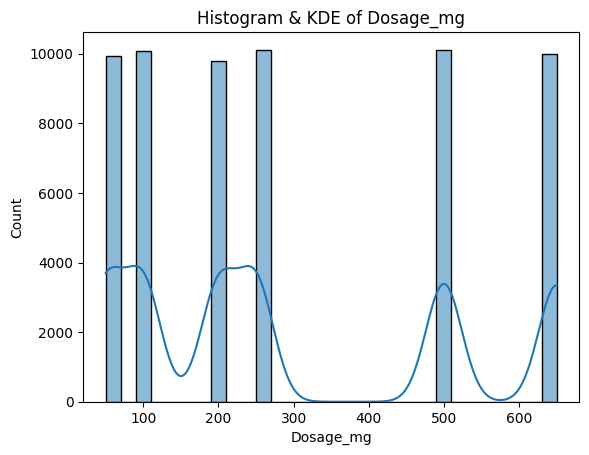

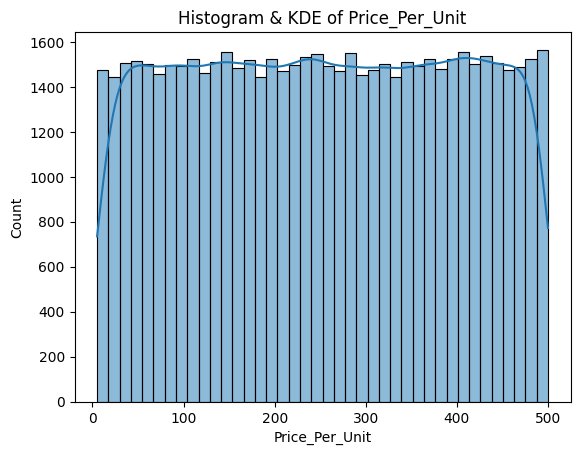

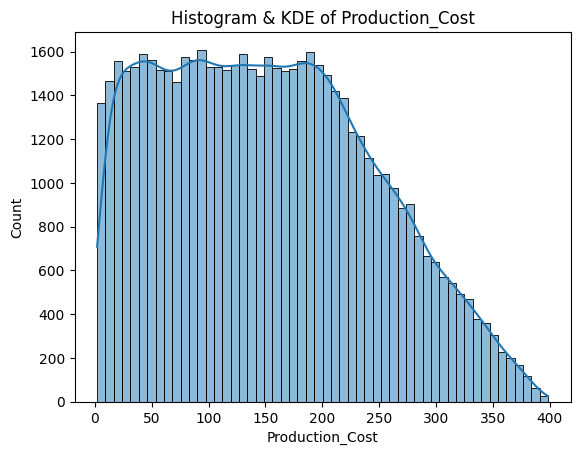

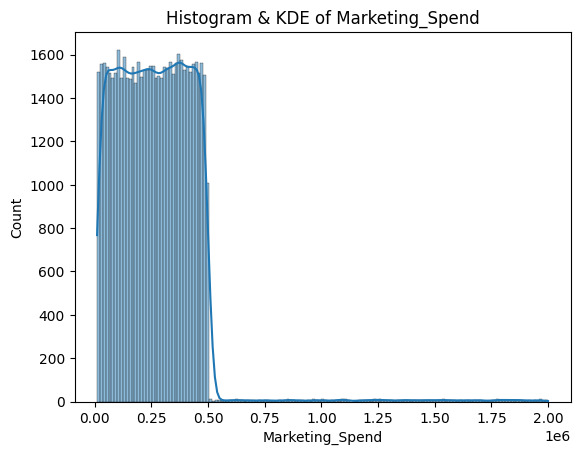

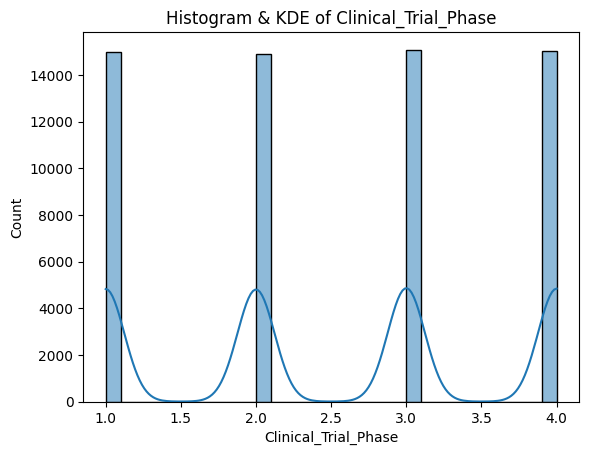

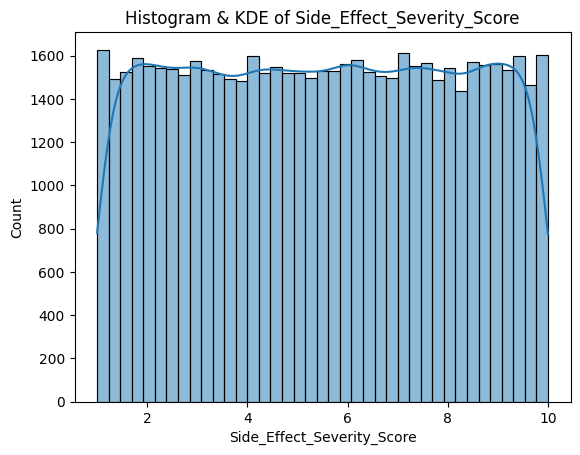

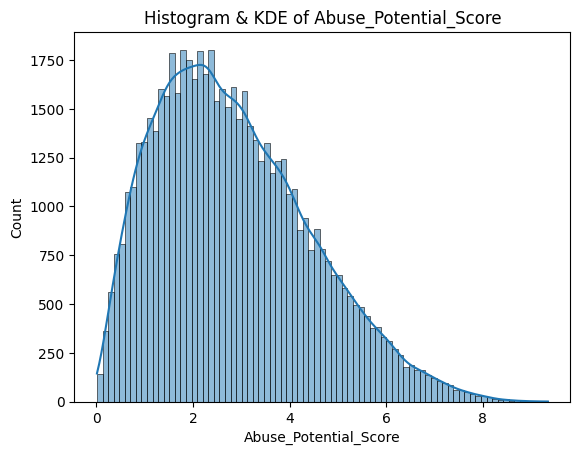

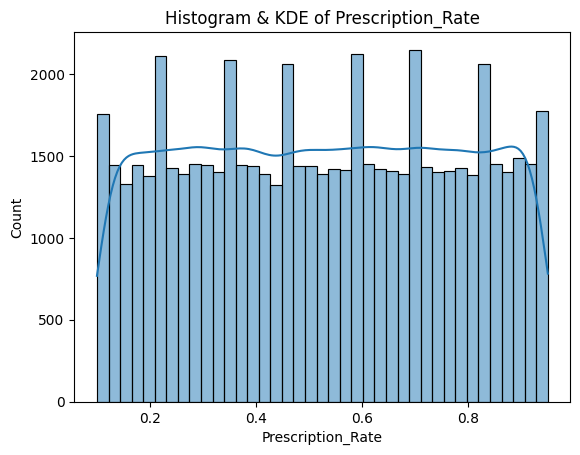

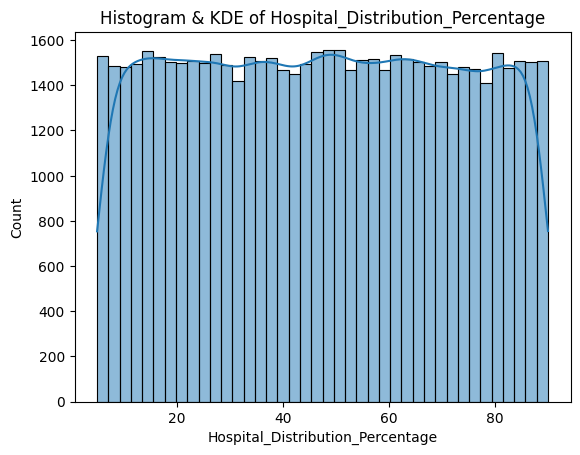

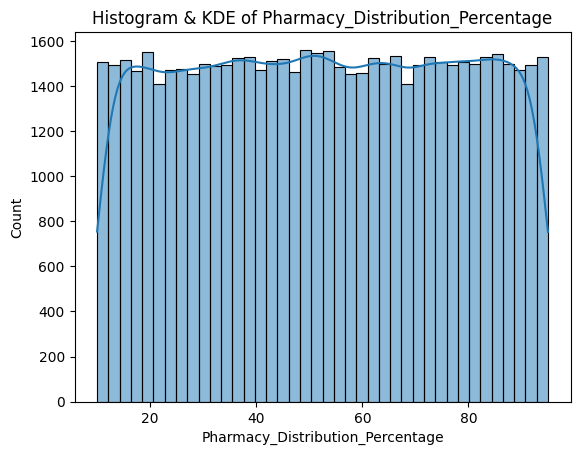

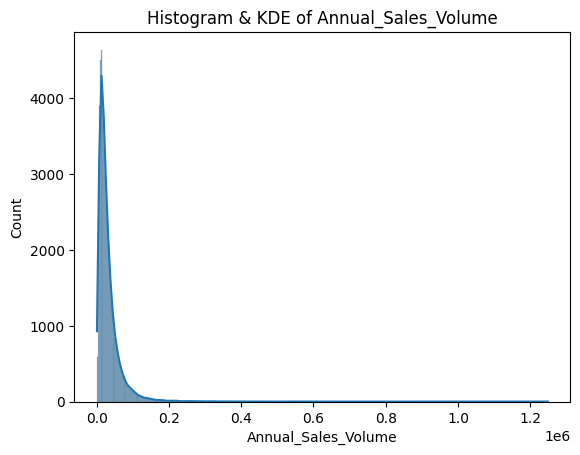

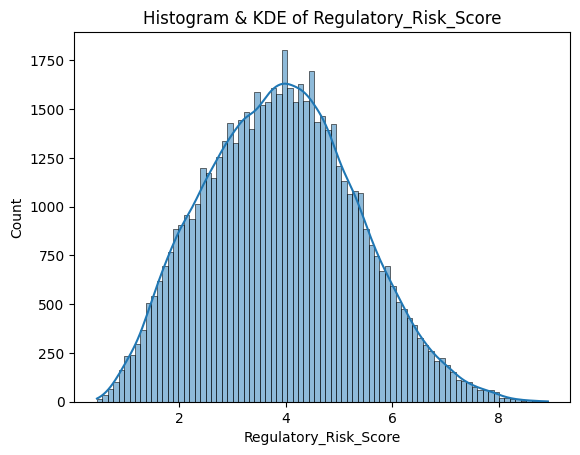

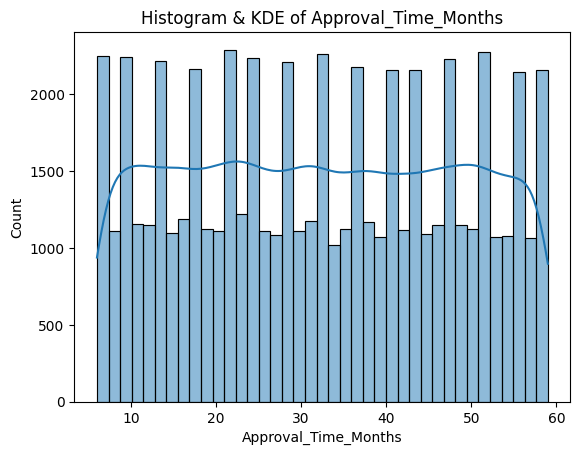

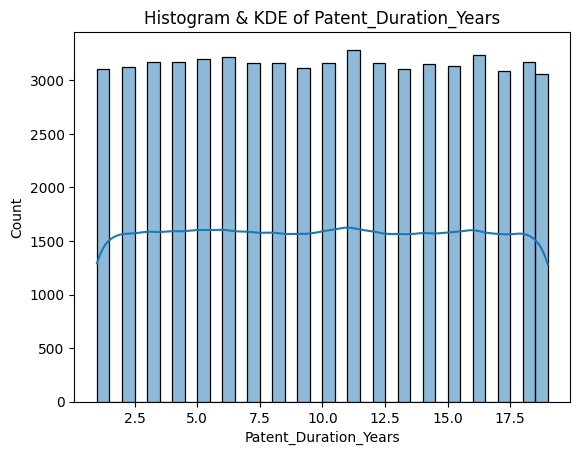

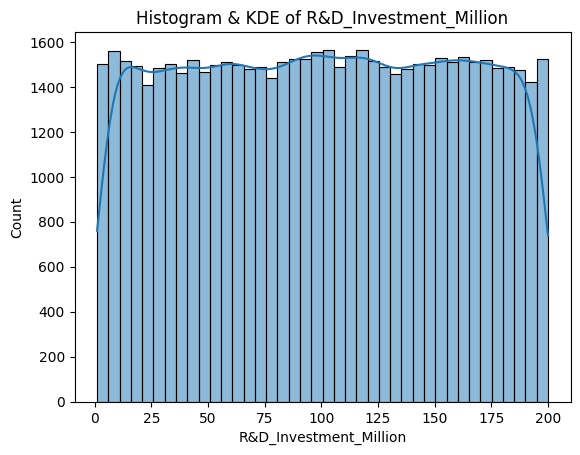

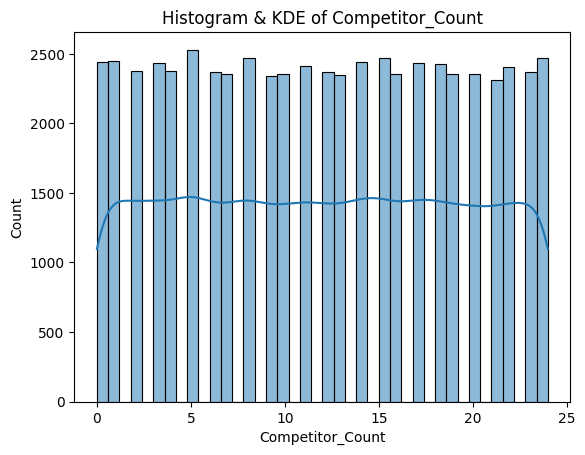

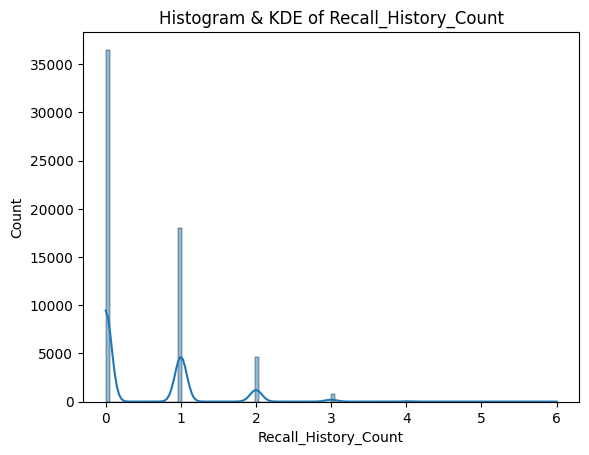

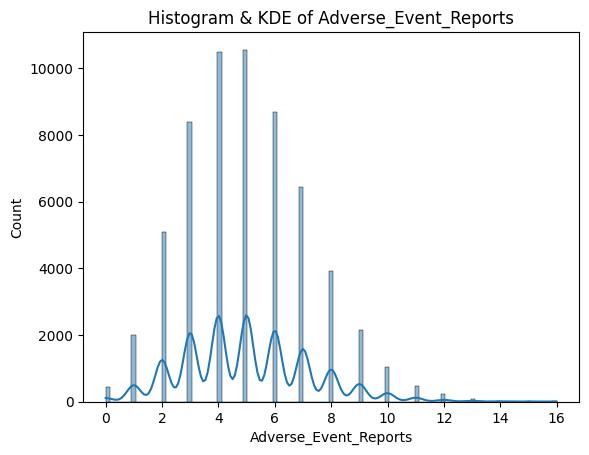

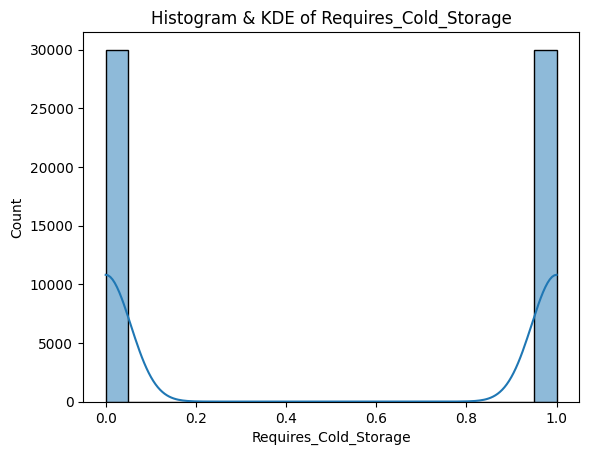

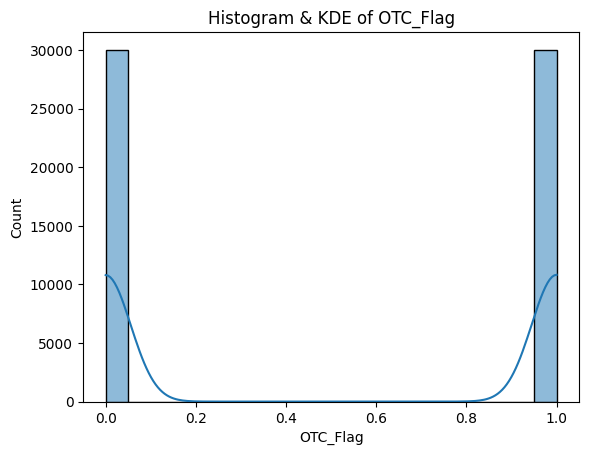

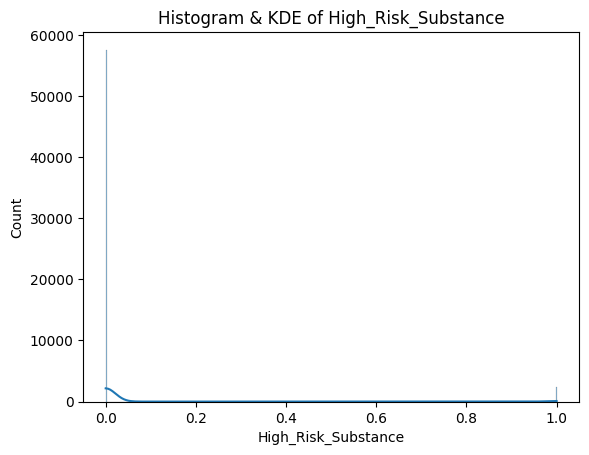

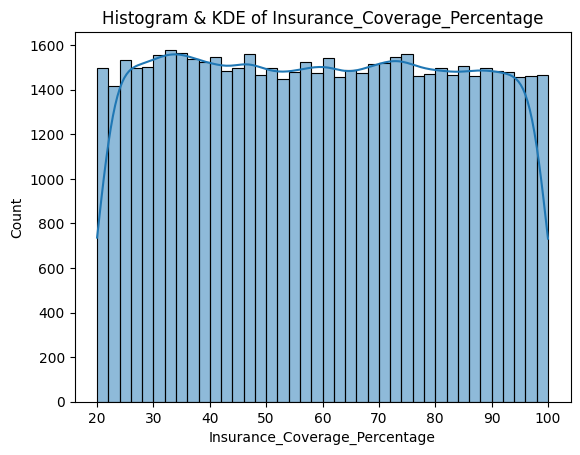

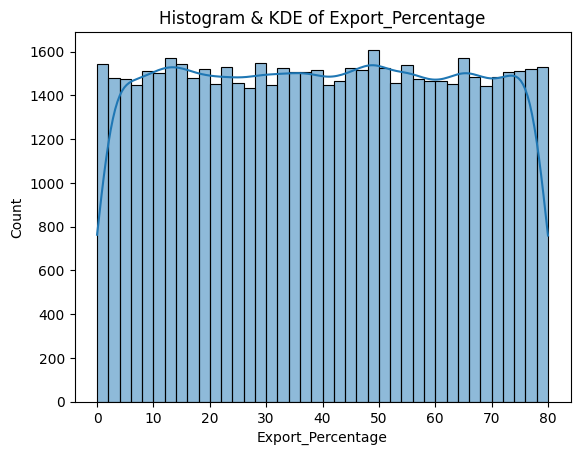

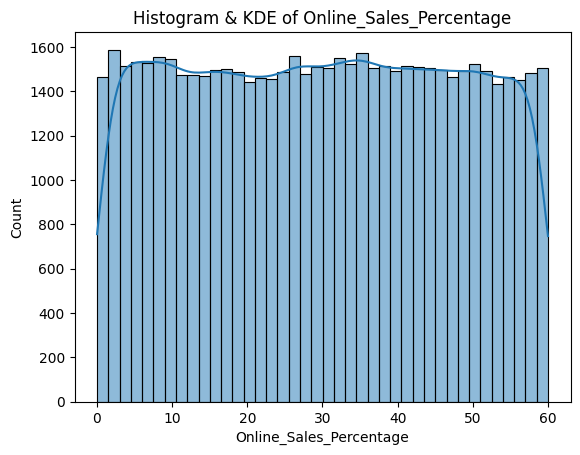

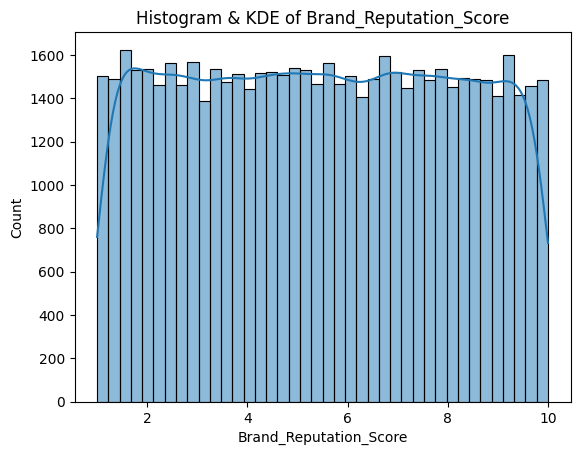

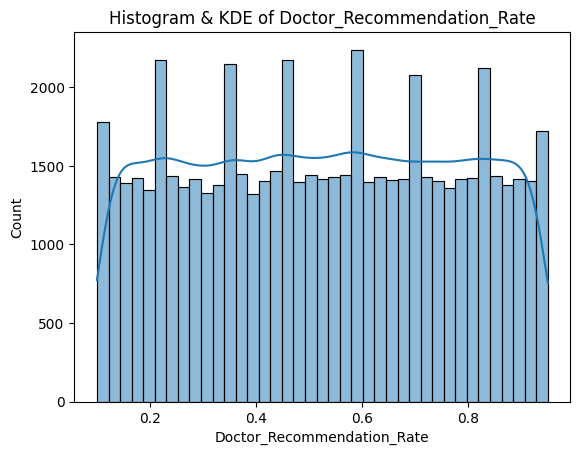

In [33]:
#histogram + KDE(distribution plot)
for col in num_cols:
    plt.figure()
    sns.histplot(dataset[col], kde=True)
    plt.title(f"Histogram & KDE of {col}")
    plt.show()

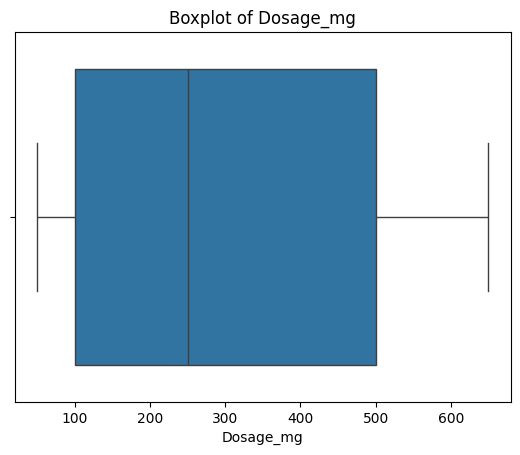

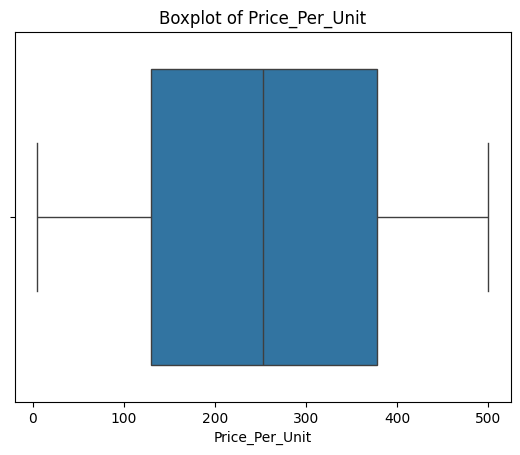

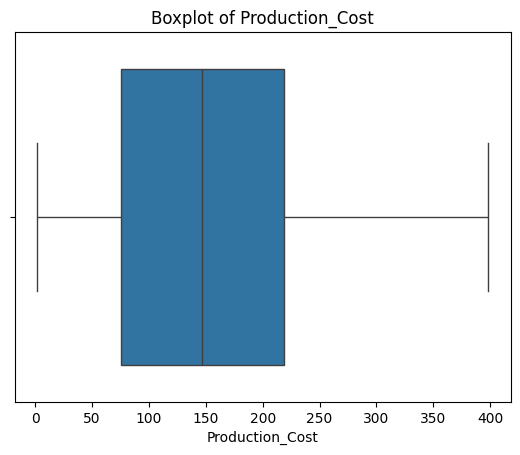

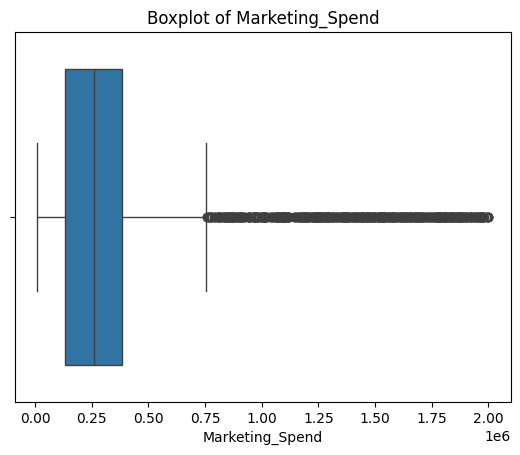

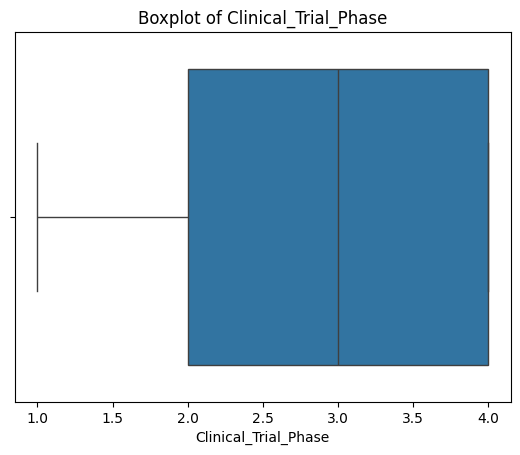

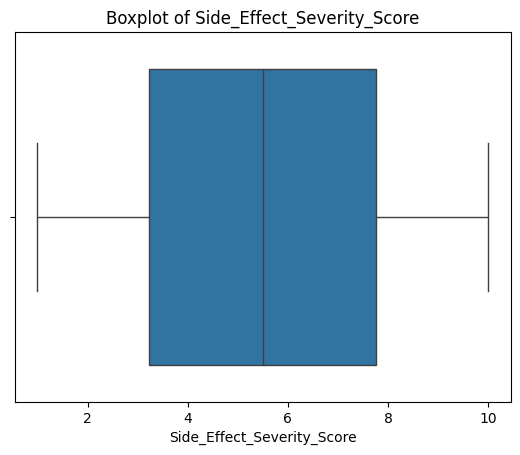

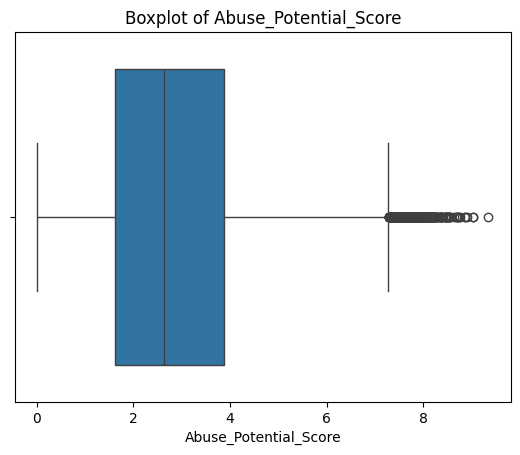

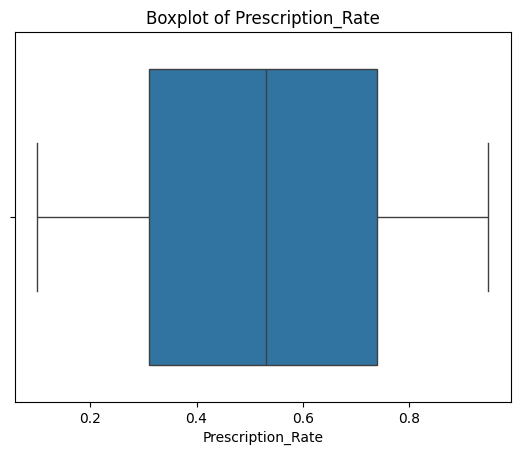

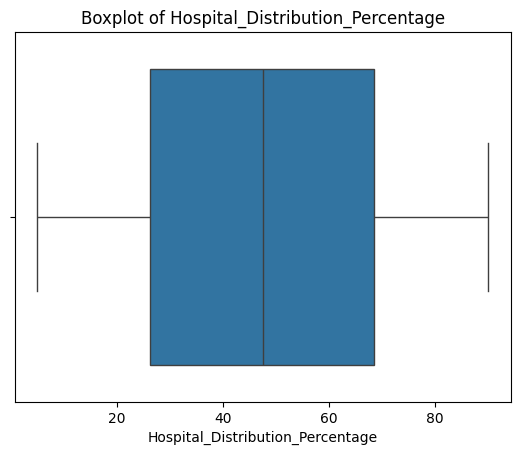

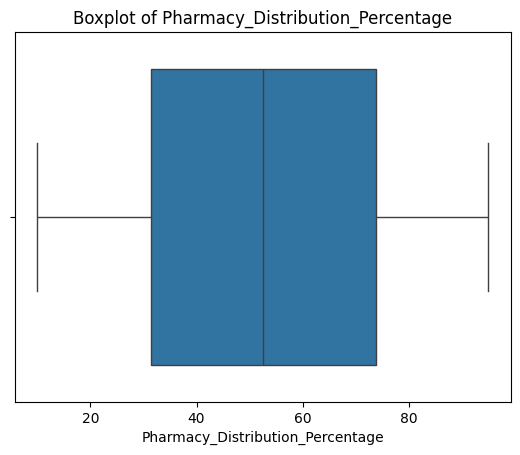

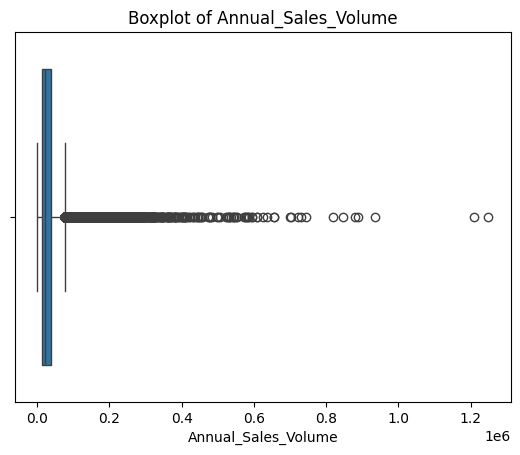

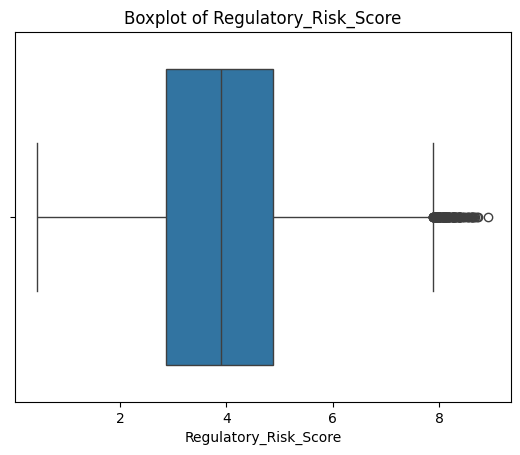

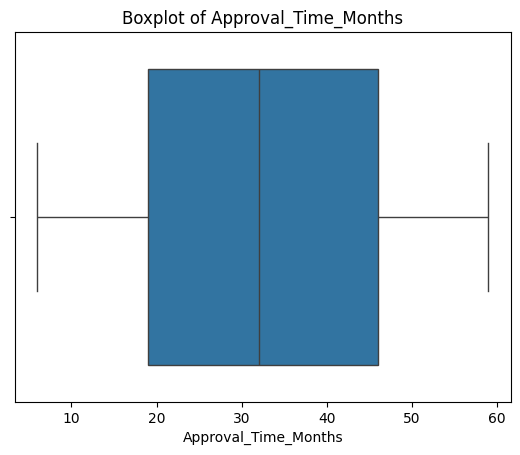

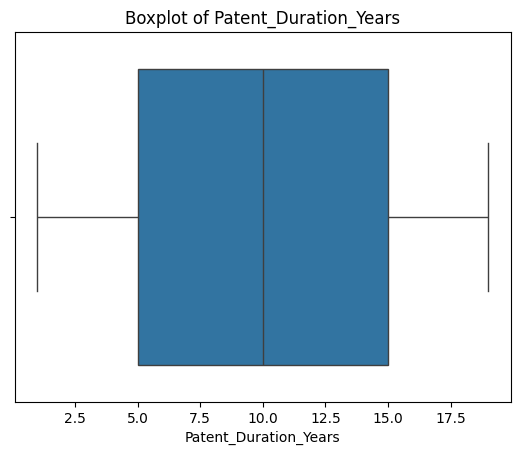

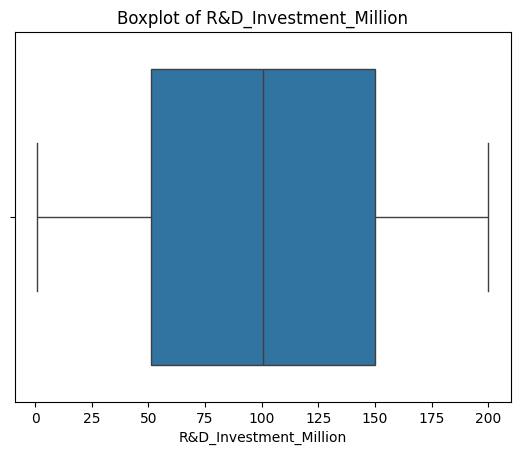

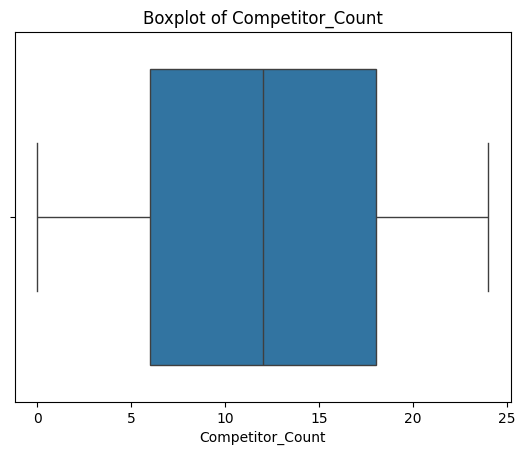

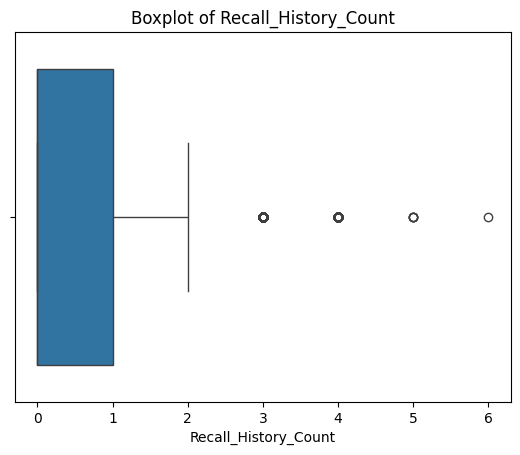

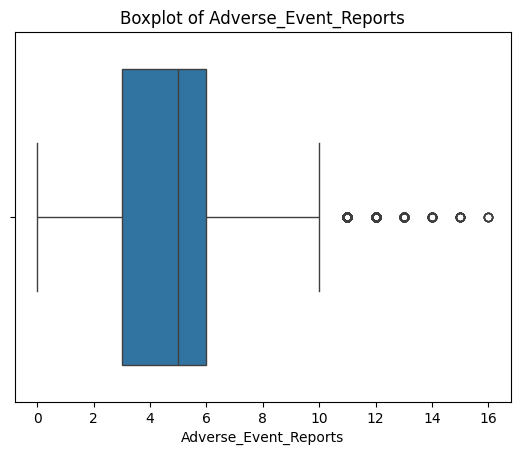

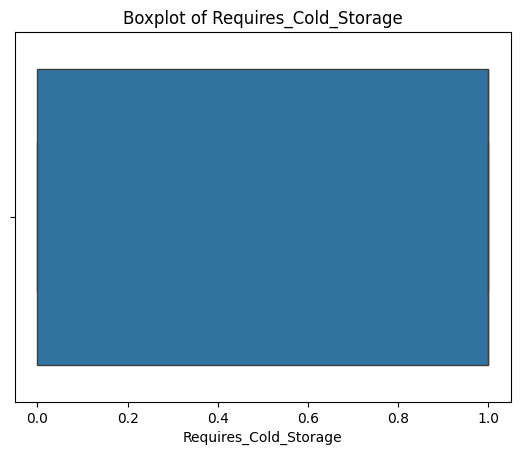

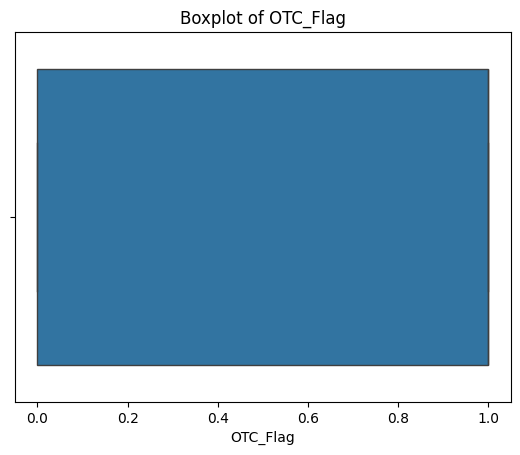

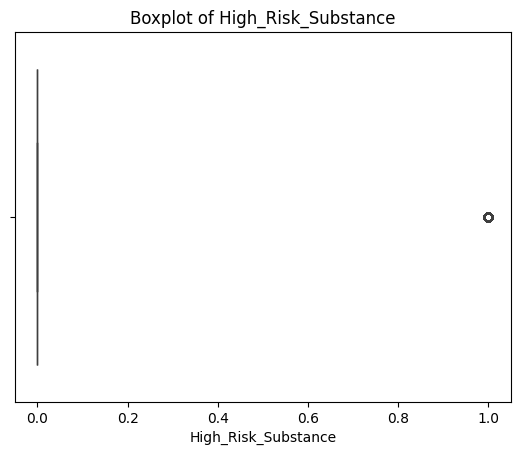

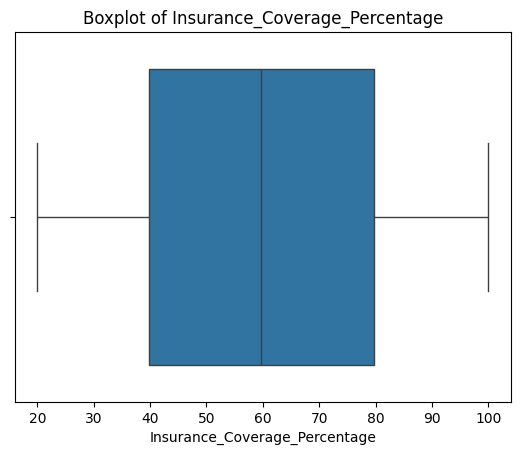

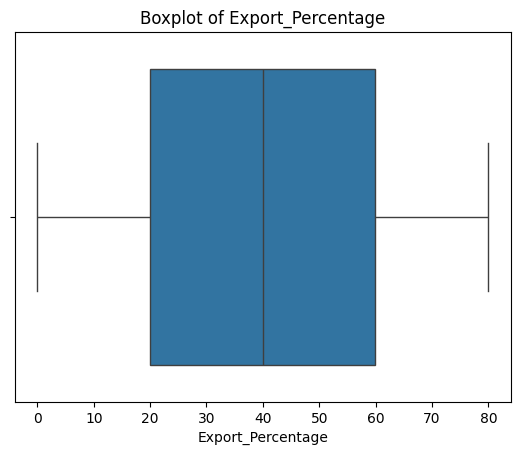

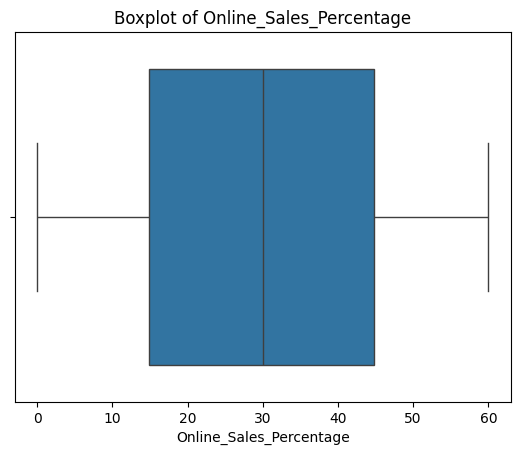

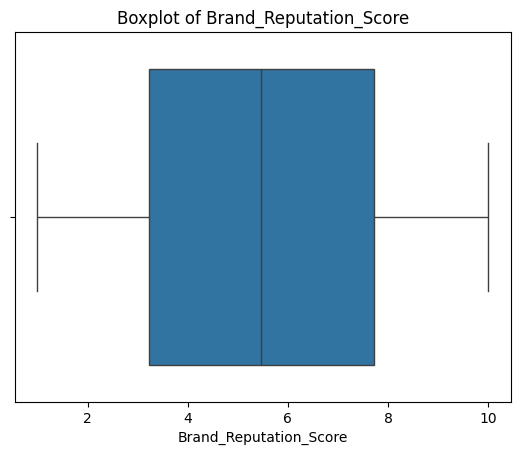

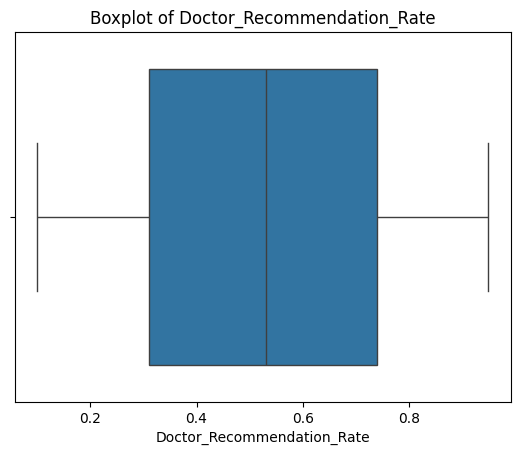

In [34]:
#boxplot for outlier detection
for col in num_cols:
    plt.figure()
    sns.boxplot(x=dataset[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

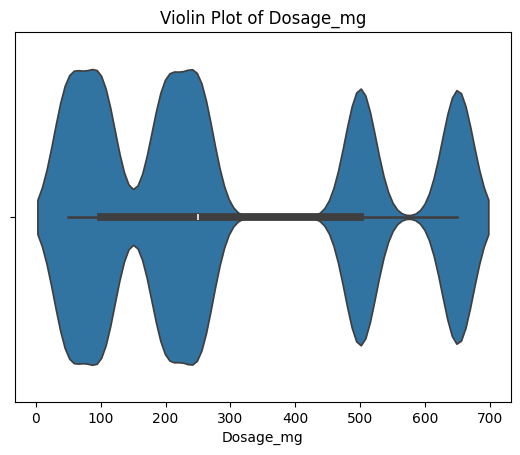

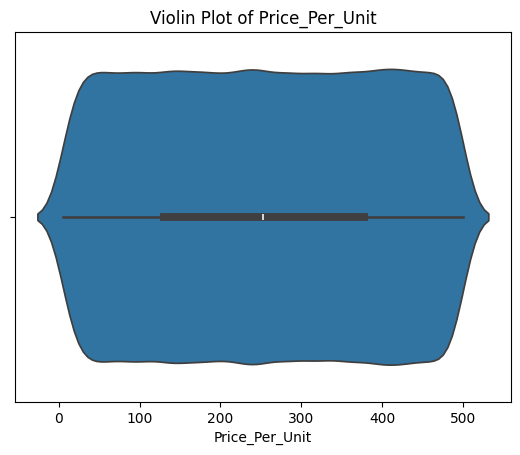

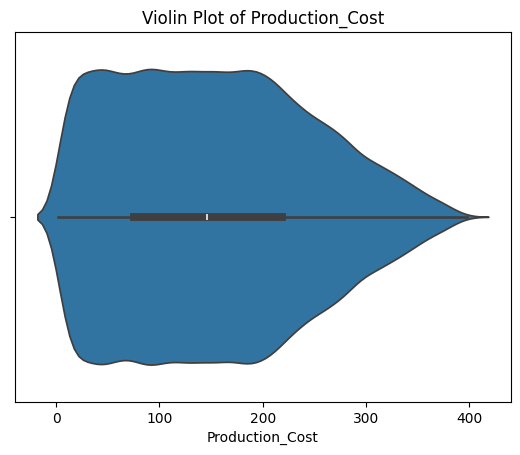

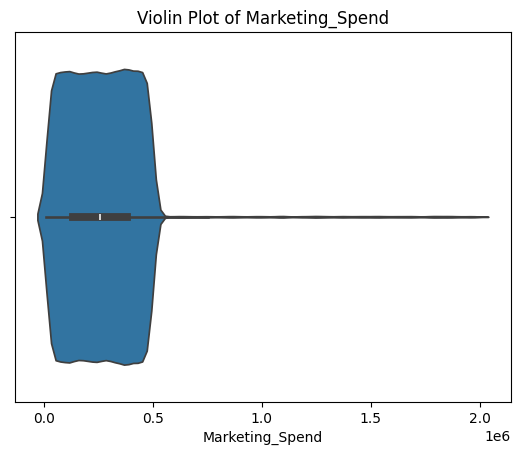

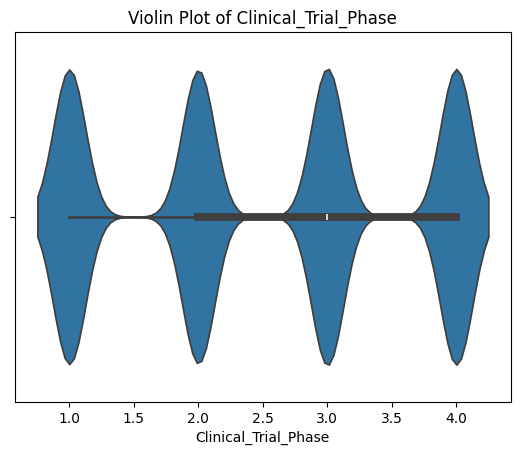

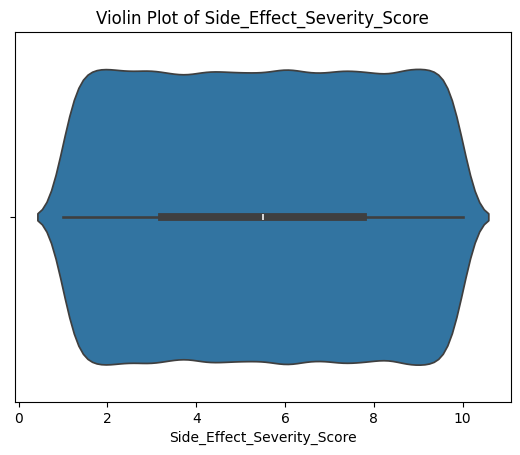

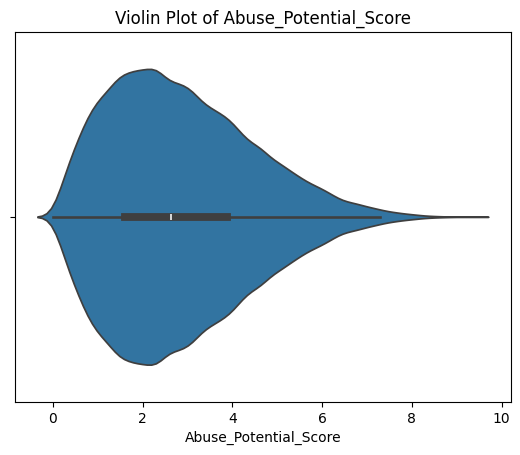

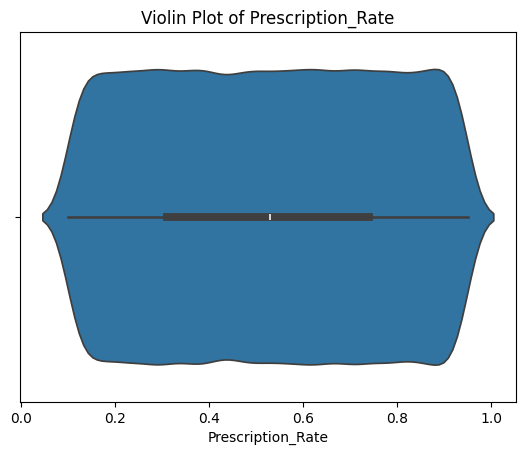

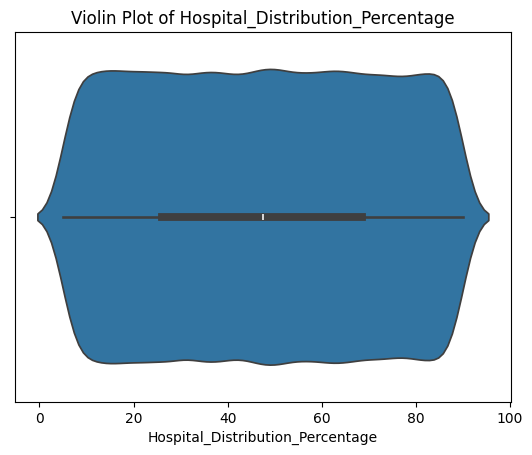

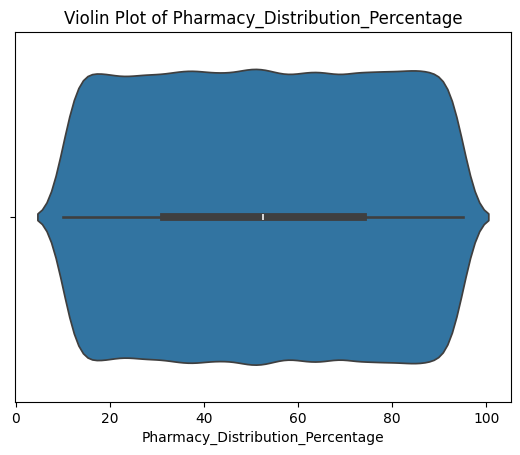

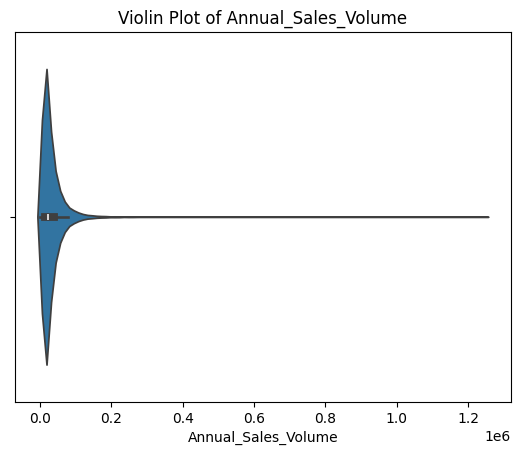

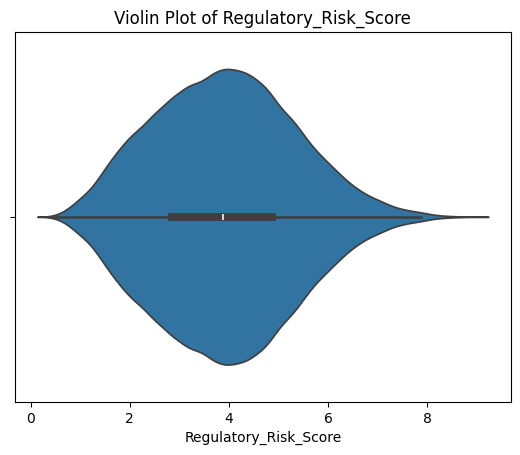

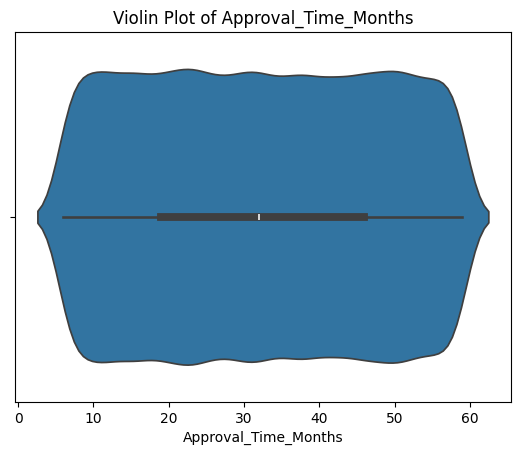

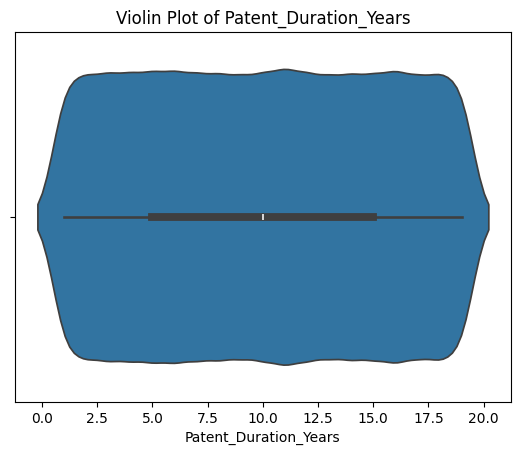

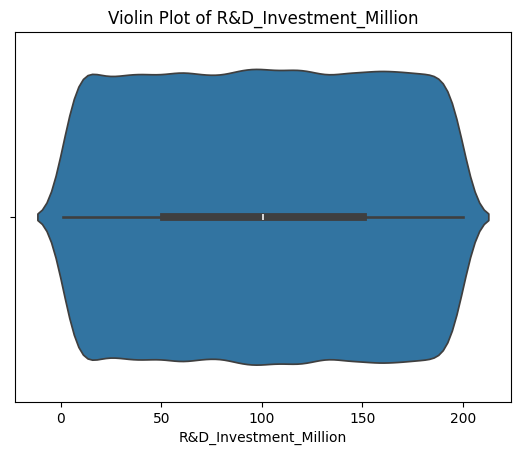

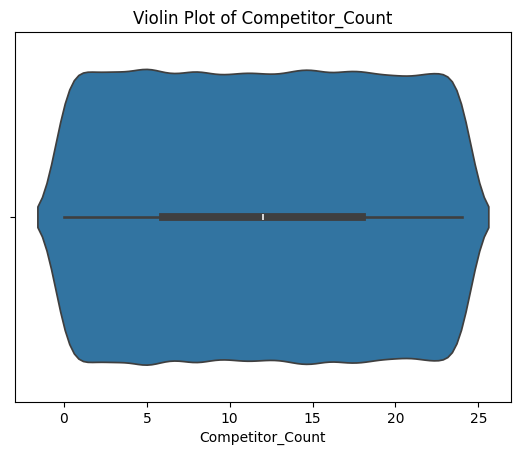

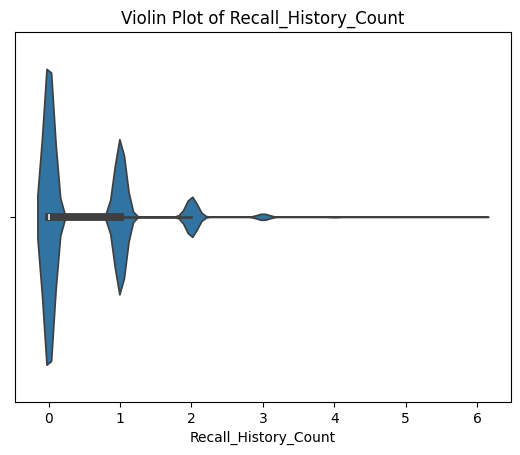

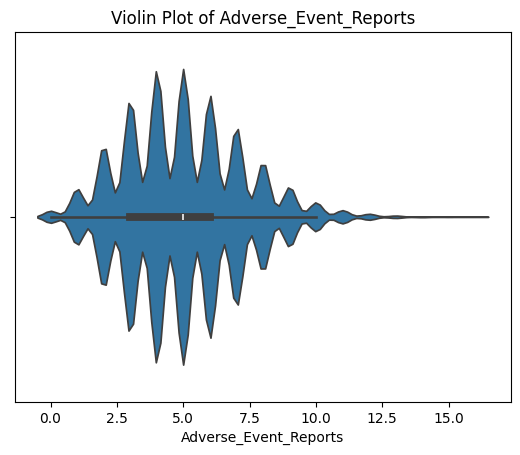

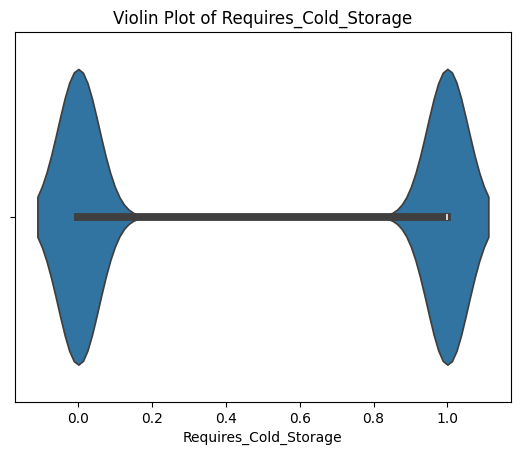

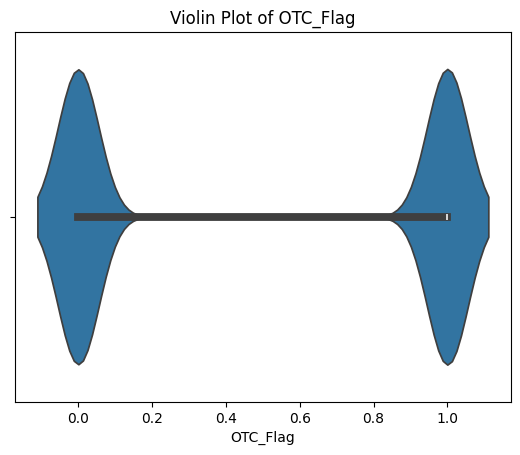

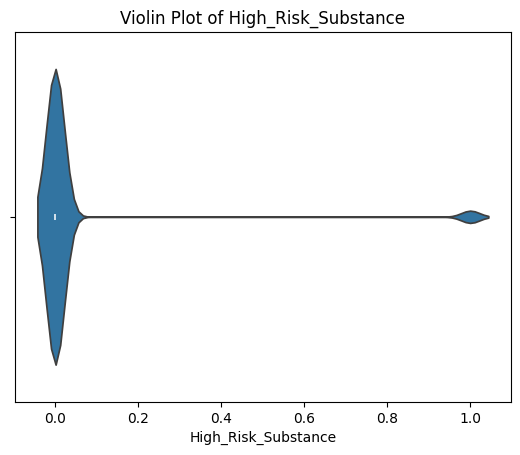

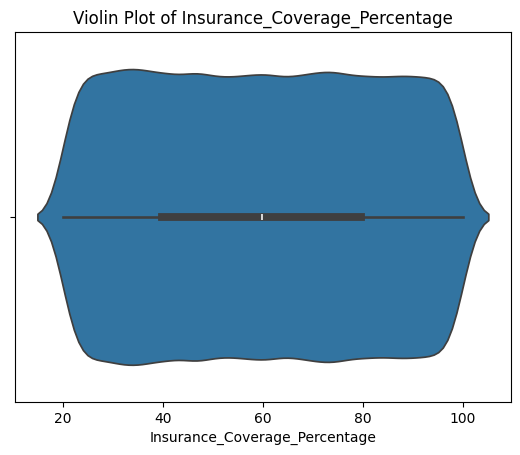

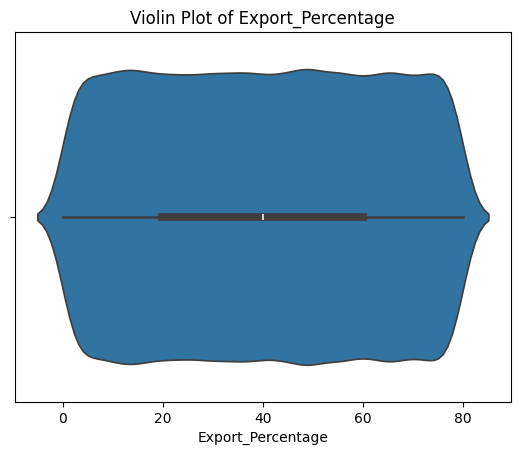

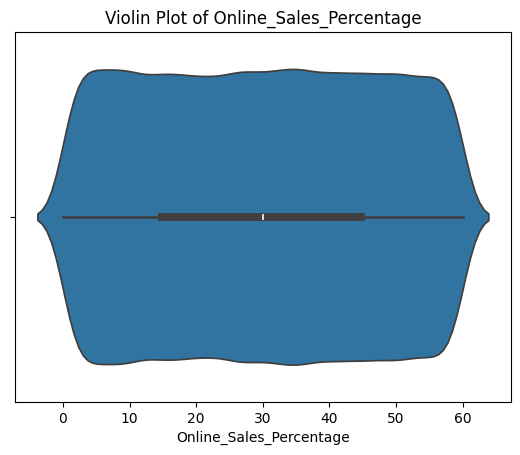

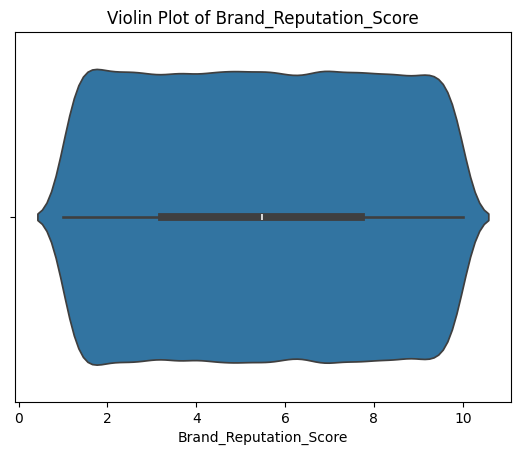

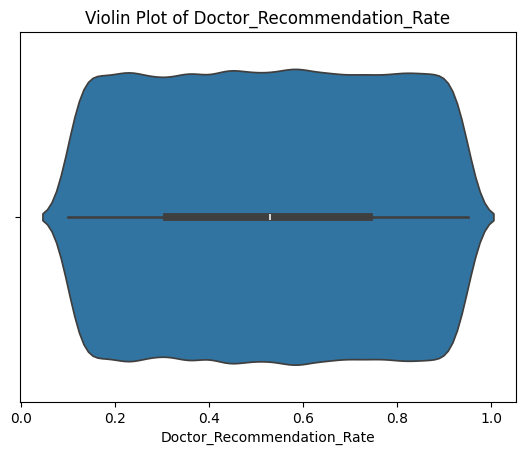

In [35]:
#violin plot for distribution and density detection
for col in num_cols:
    plt.figure()
    sns.violinplot(x = dataset[col])
    plt.title(f"Violin Plot of {col}")
    plt.show()

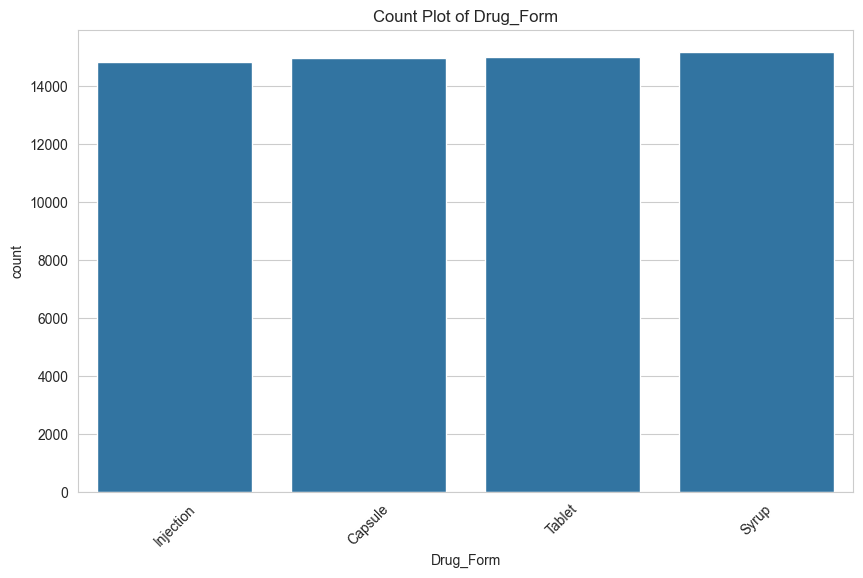

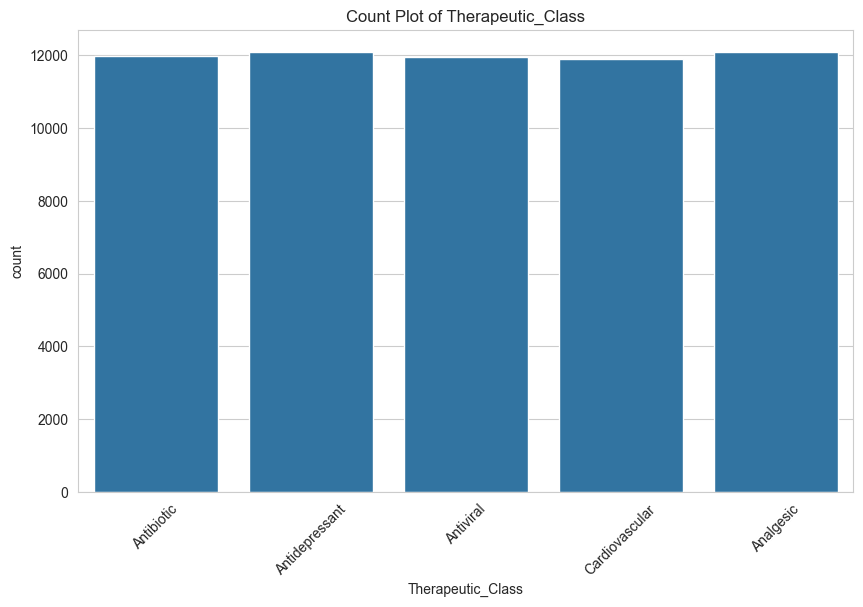

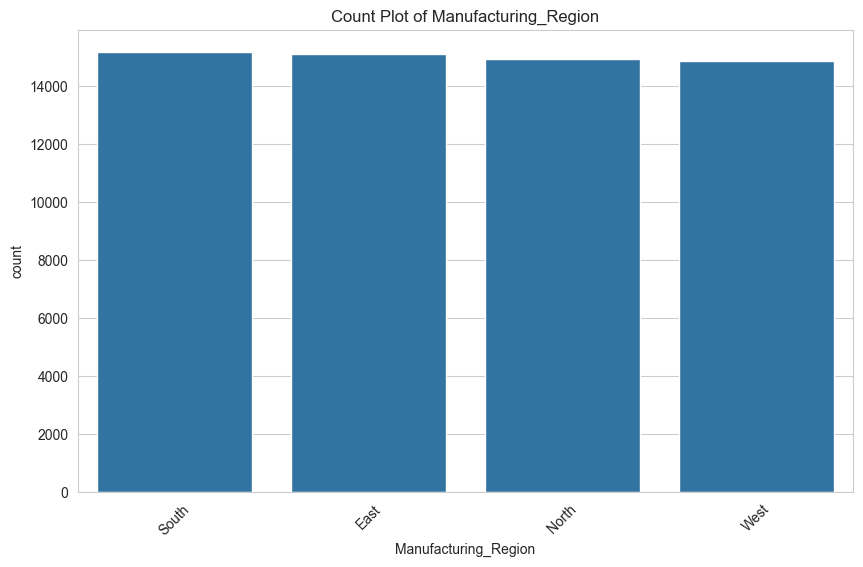

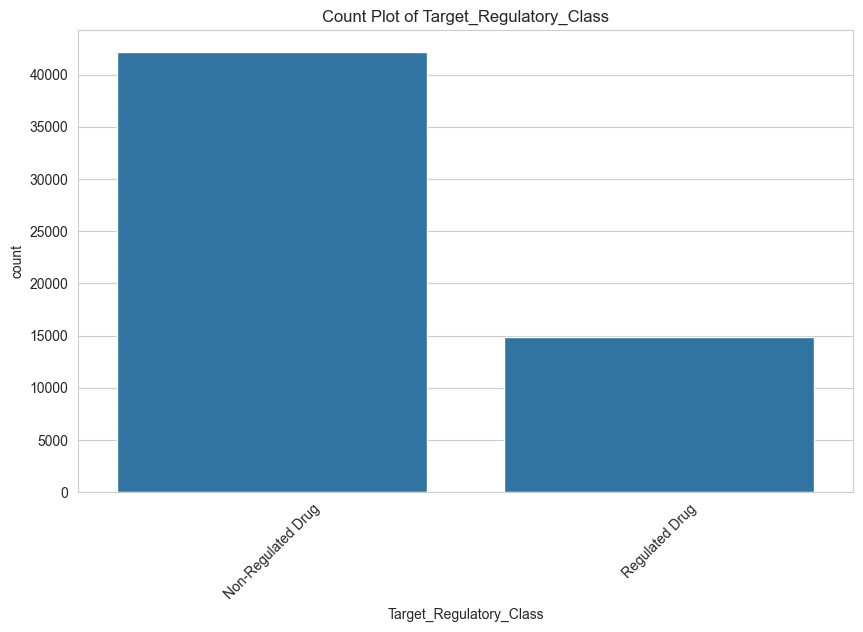

In [23]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x = dataset[col])
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()

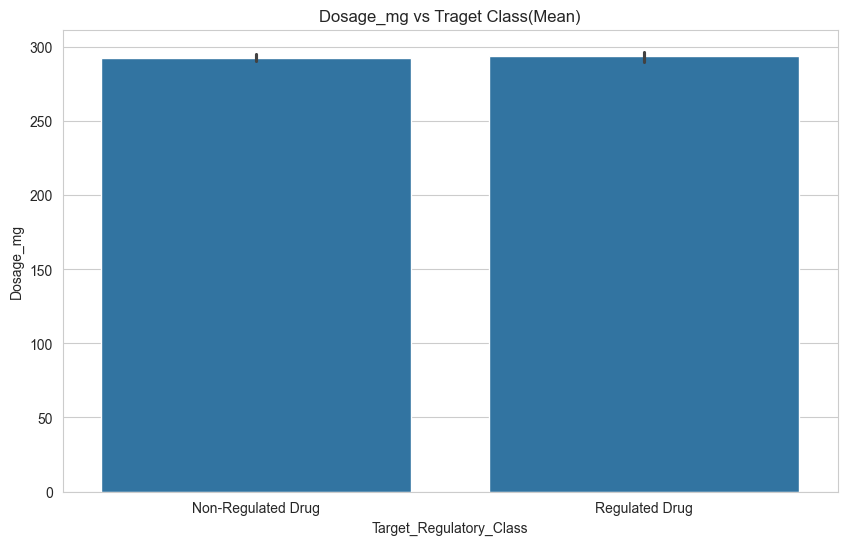

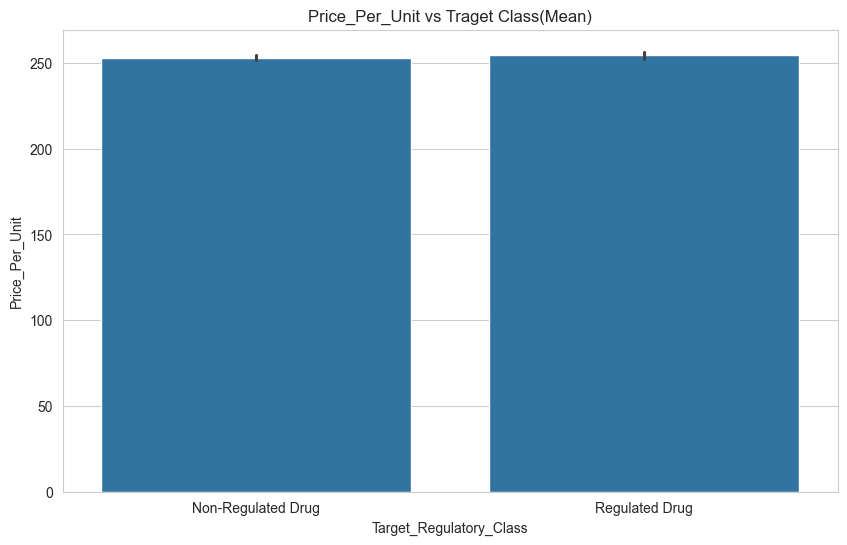

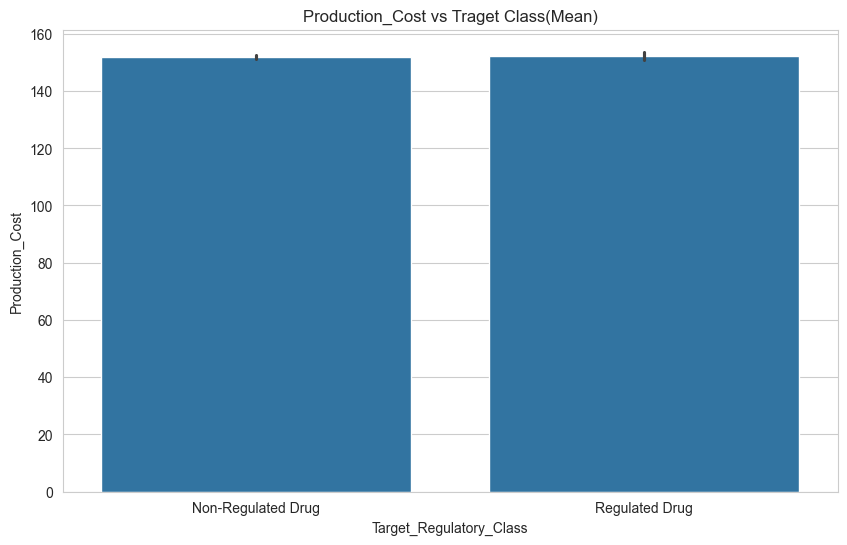

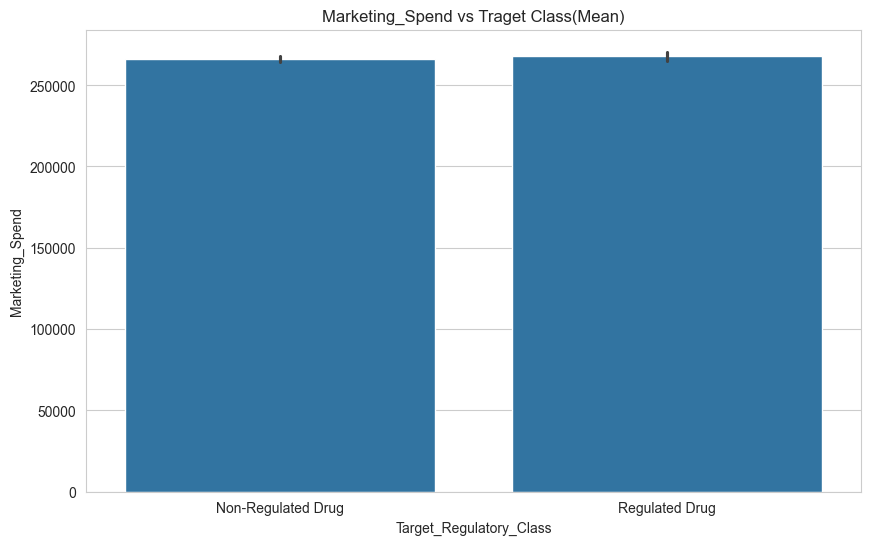

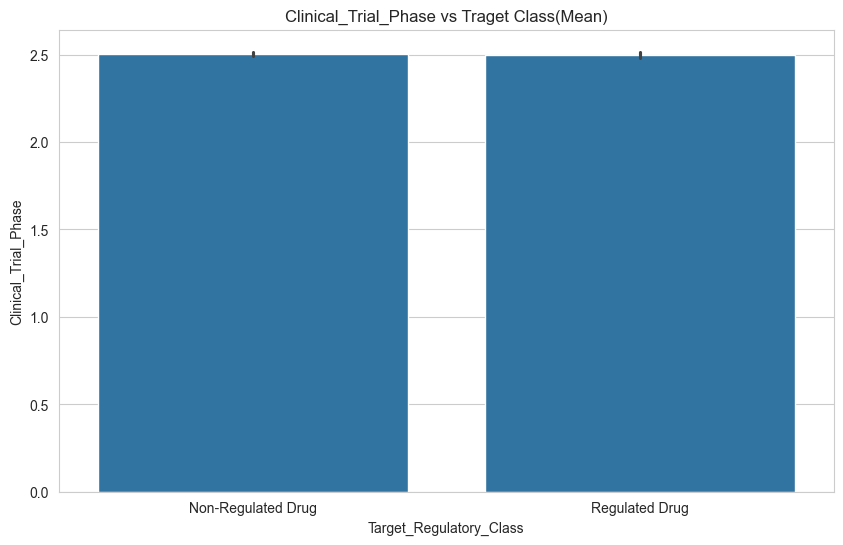

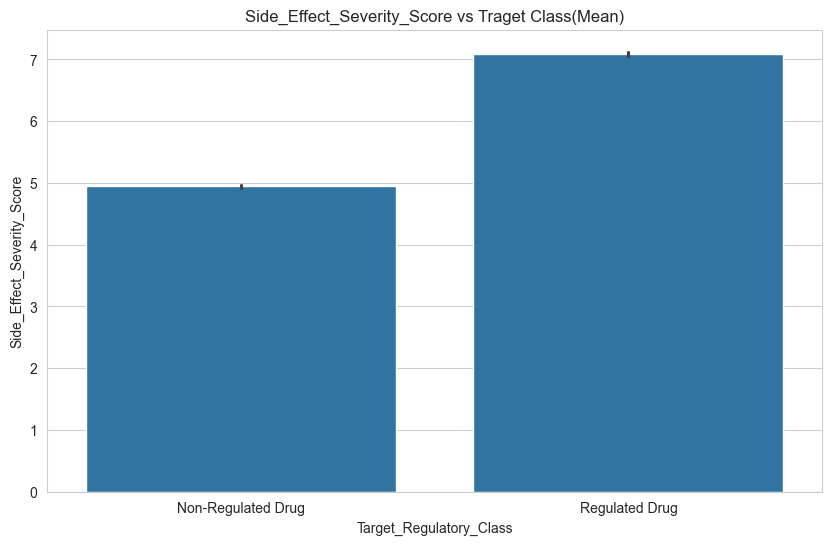

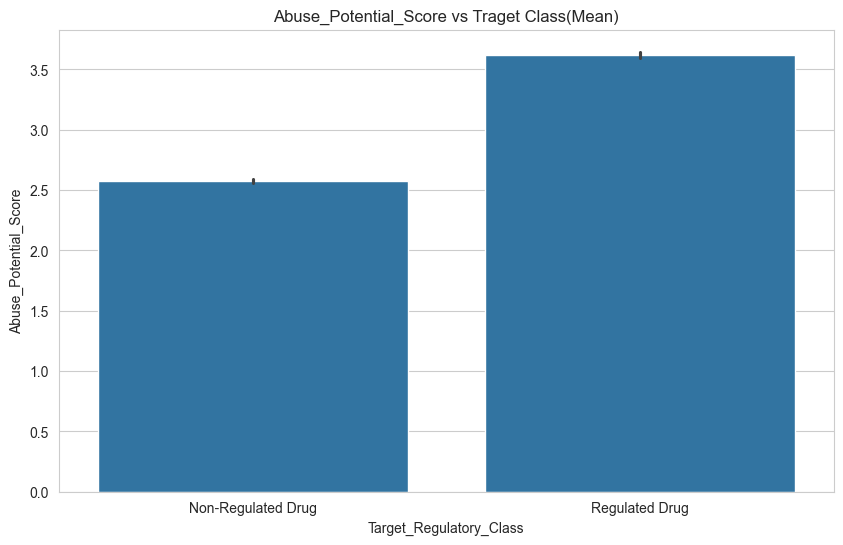

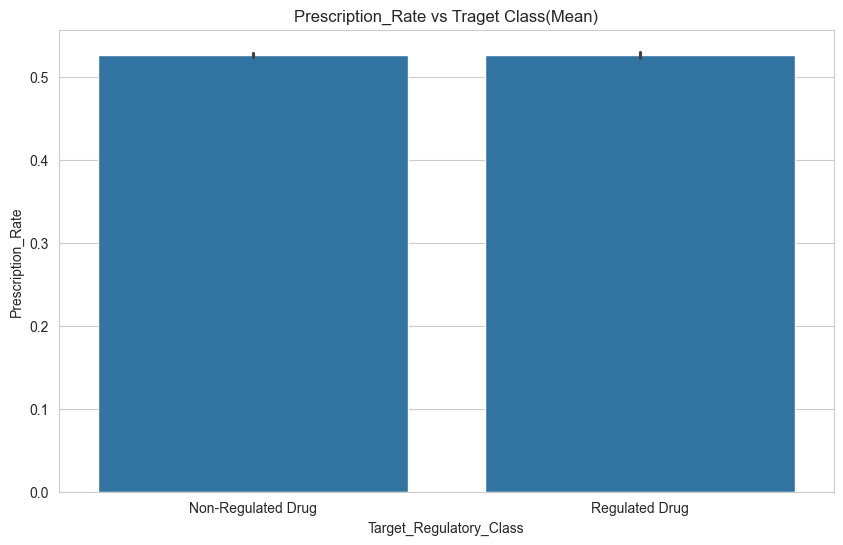

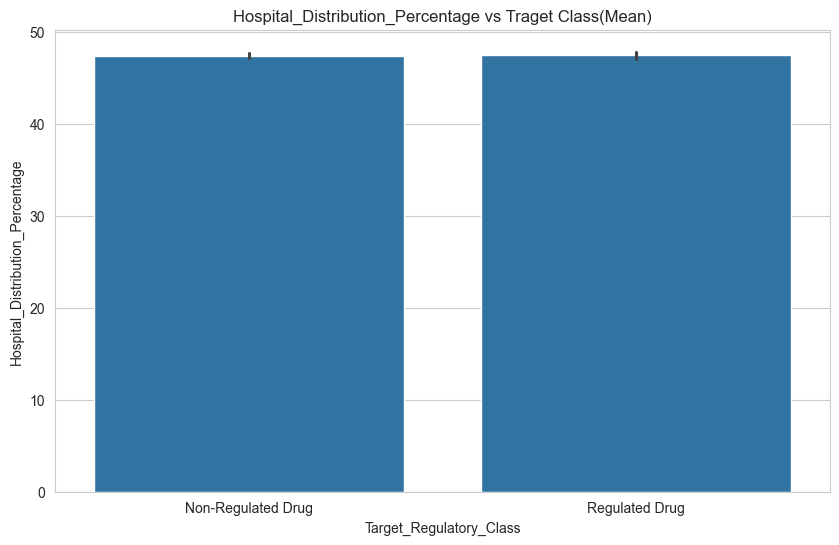

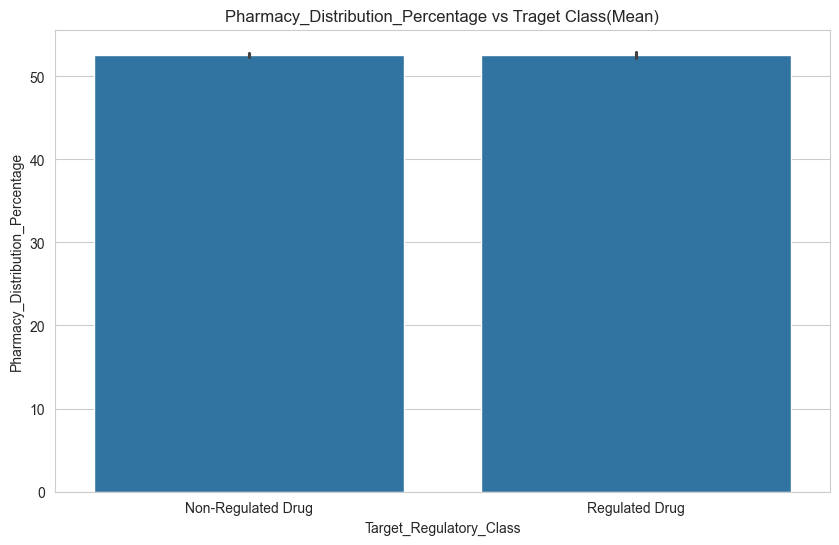

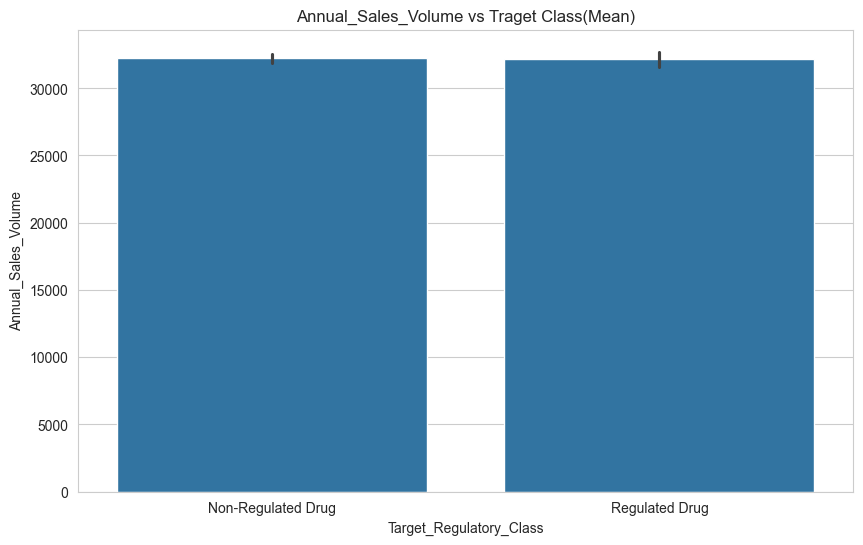

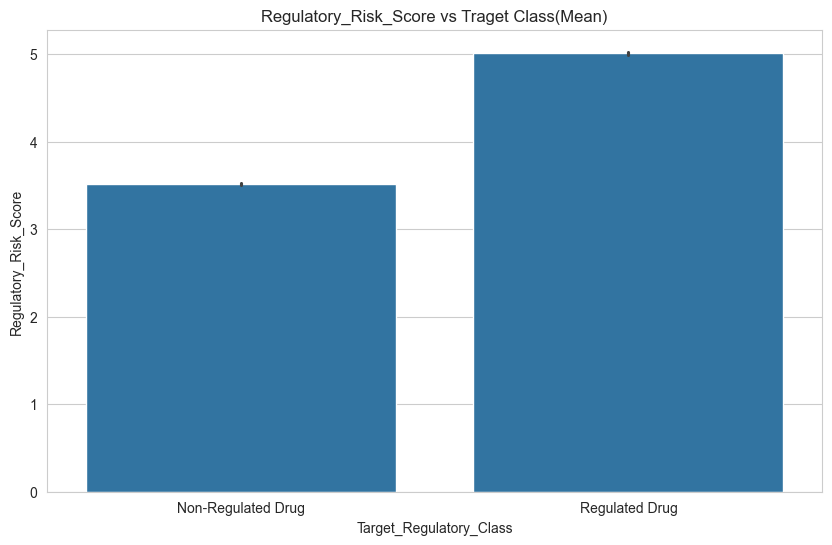

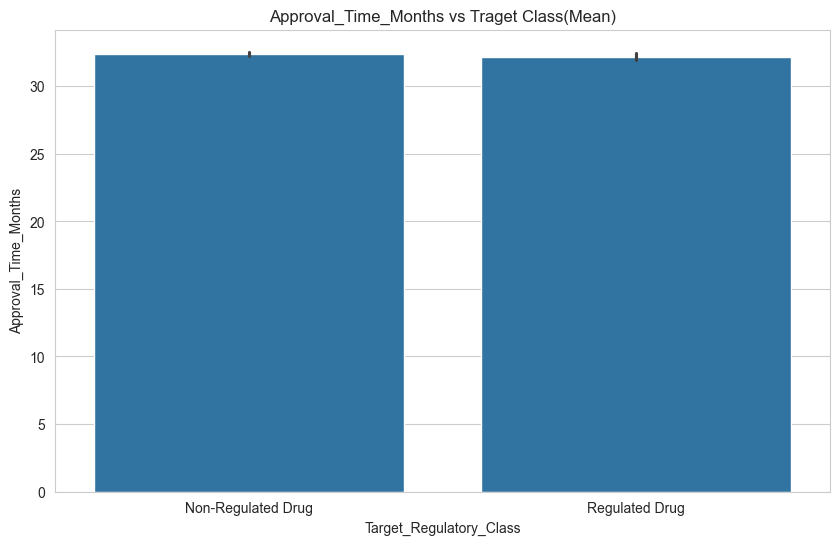

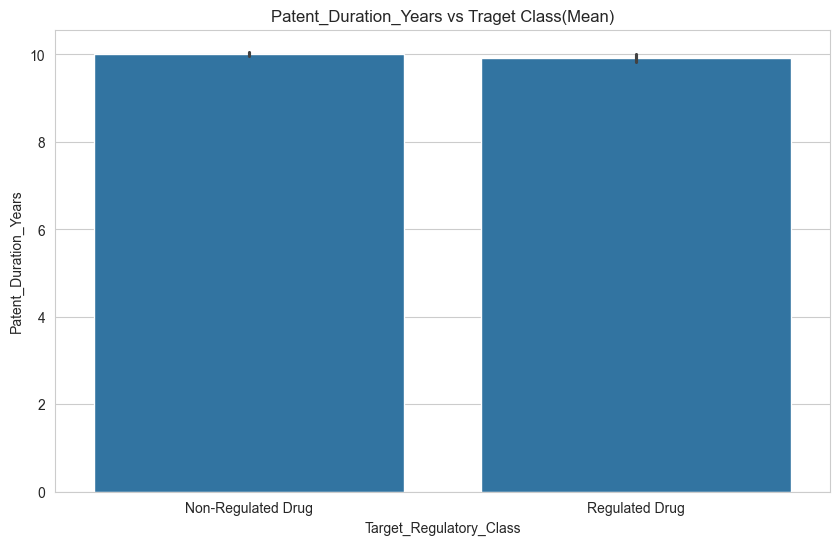

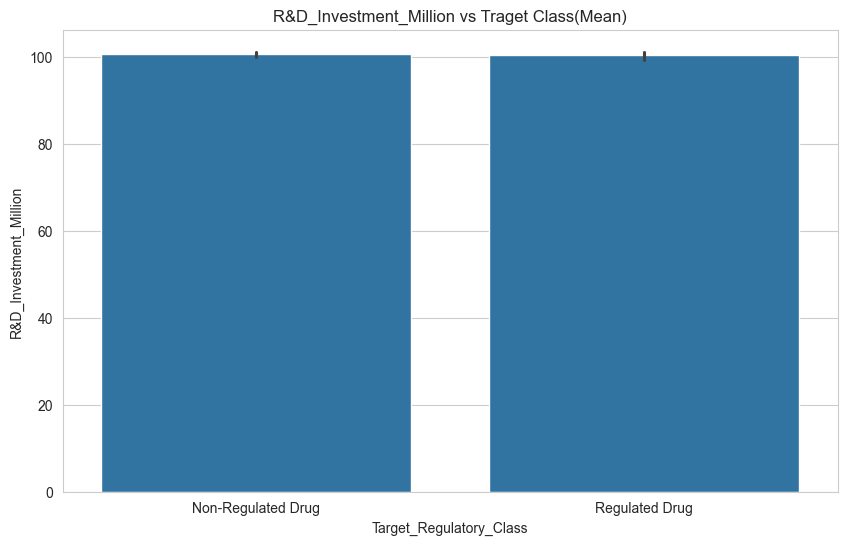

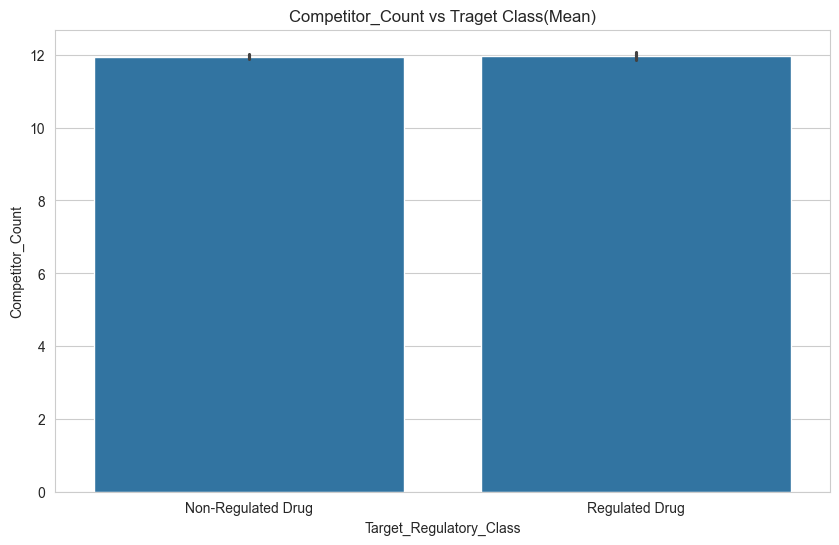

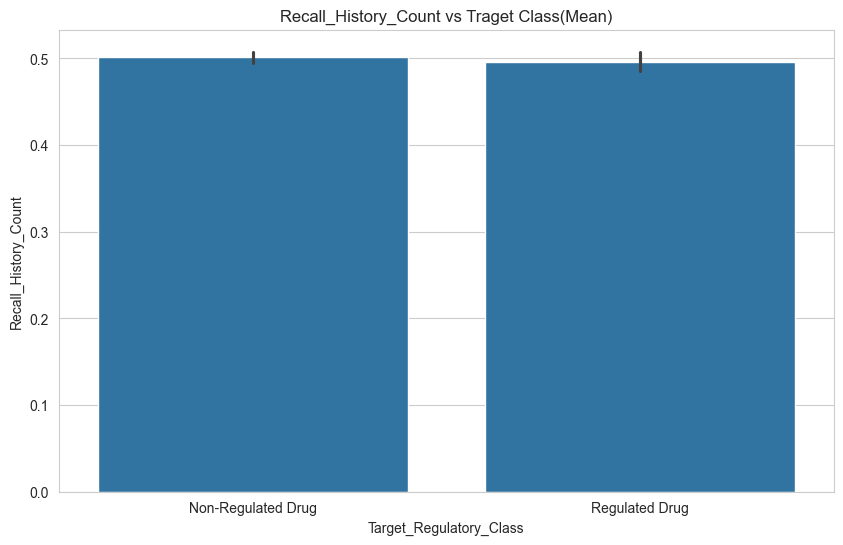

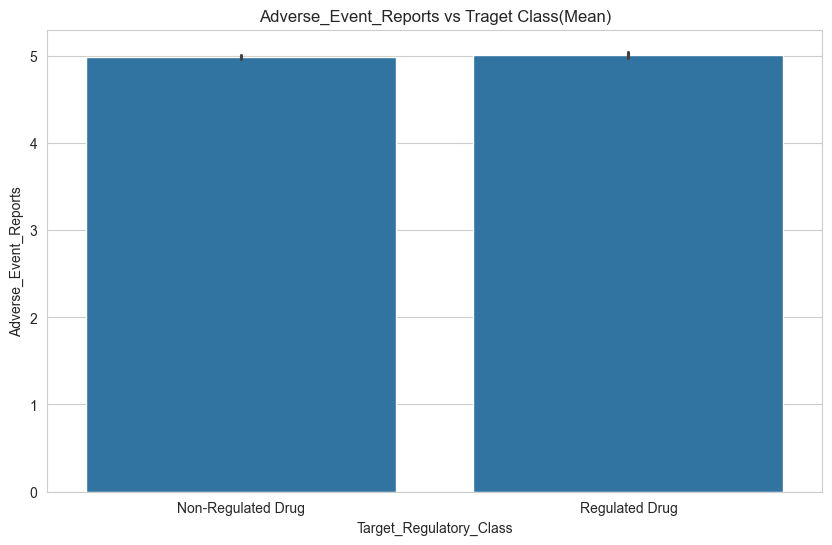

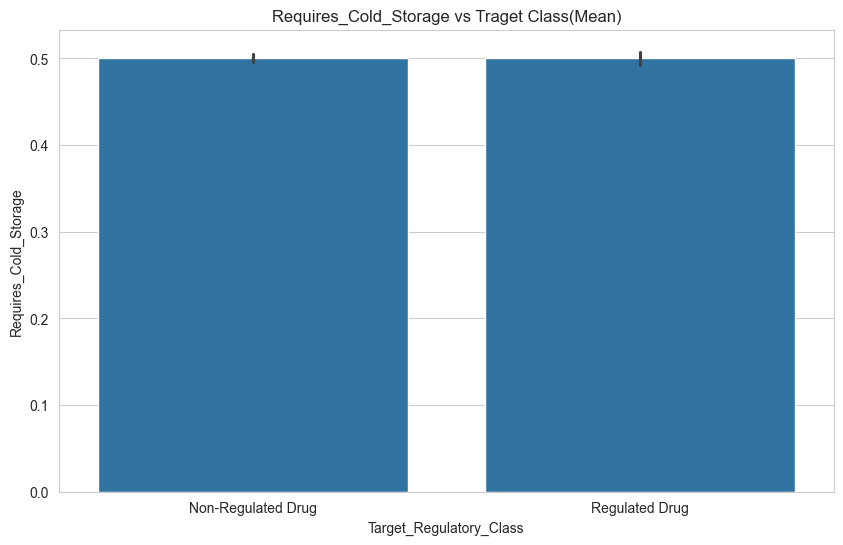

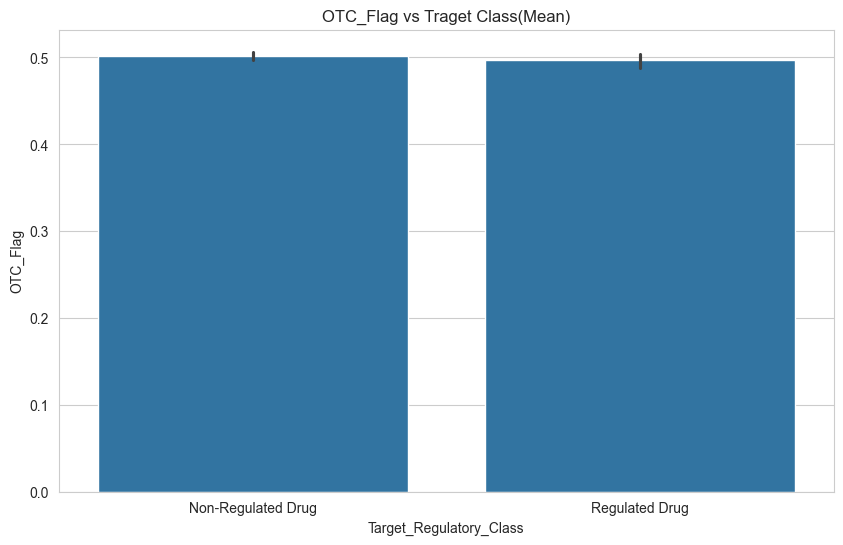

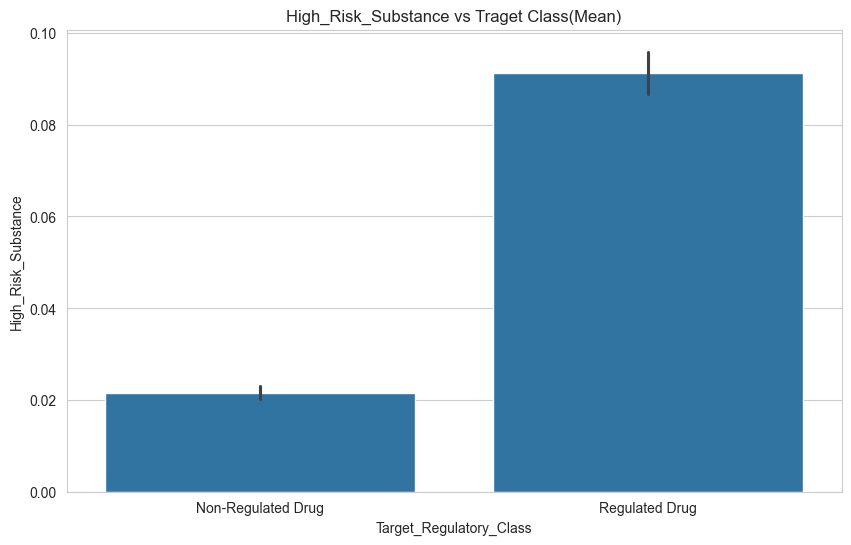

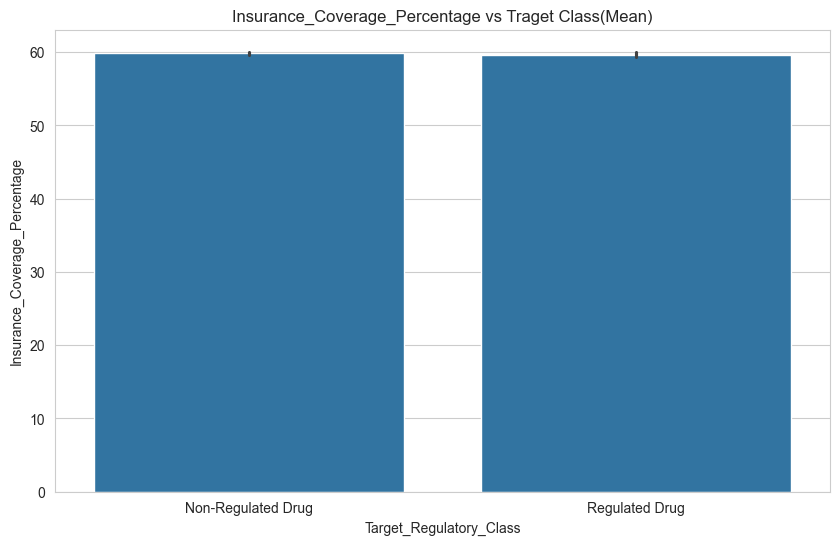

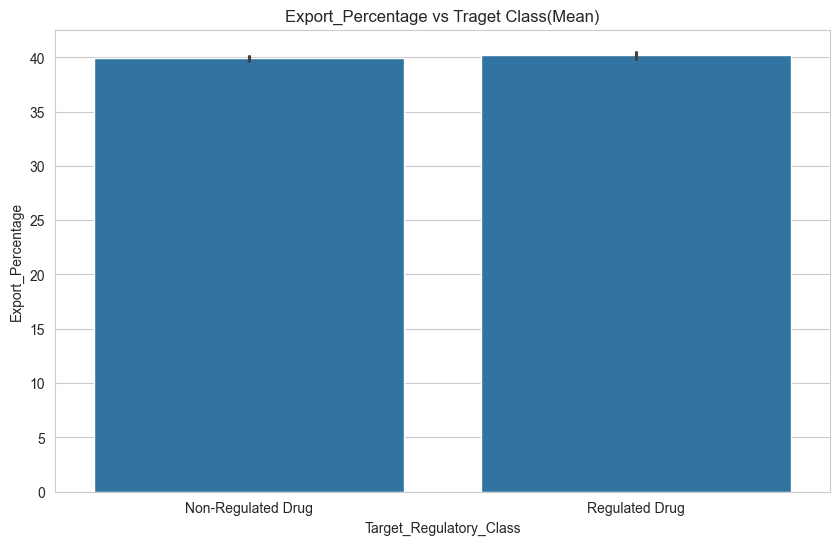

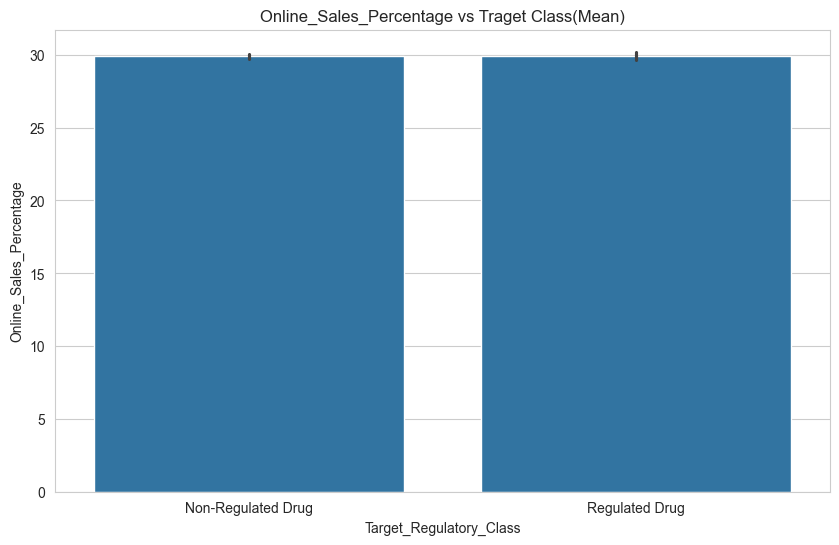

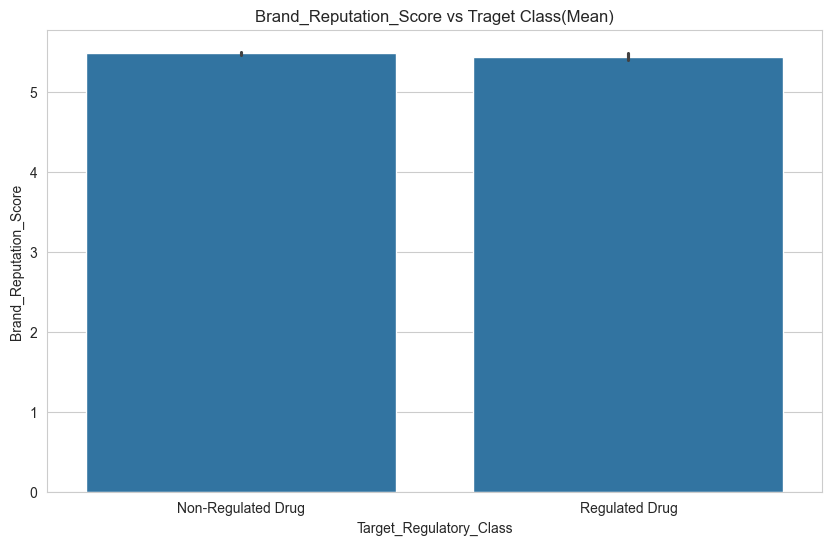

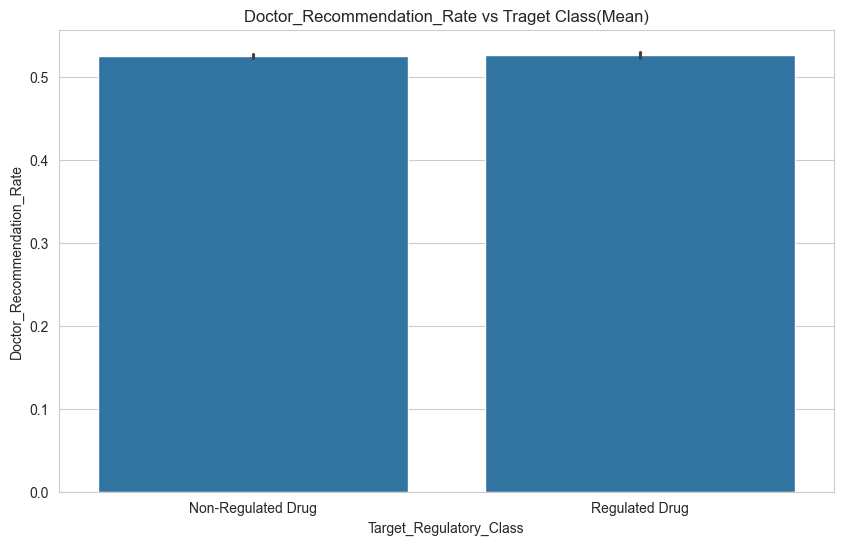

In [24]:
for col in num_cols:
    plt.figure()
    sns.barplot(x = "Target_Regulatory_Class", y = col, data = dataset)
    plt.title(f"{col} vs Traget Class(Mean)")
    plt.show()

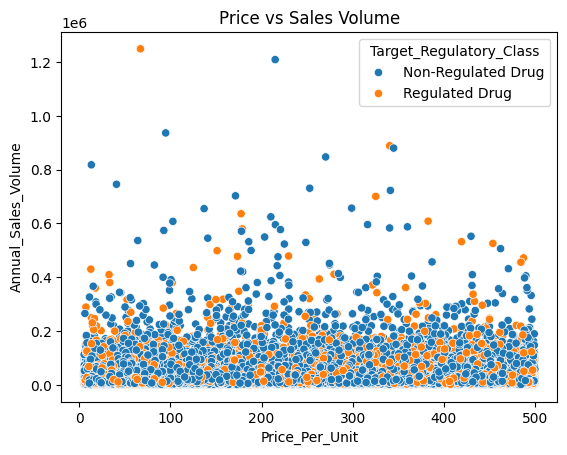

In [36]:
#Scatter plot for relationship analysis
sns.scatterplot(x="Price_Per_Unit", y="Annual_Sales_Volume", hue="Target_Regulatory_Class", data = dataset)
plt.title("Price vs Sales Volume")
plt.show()

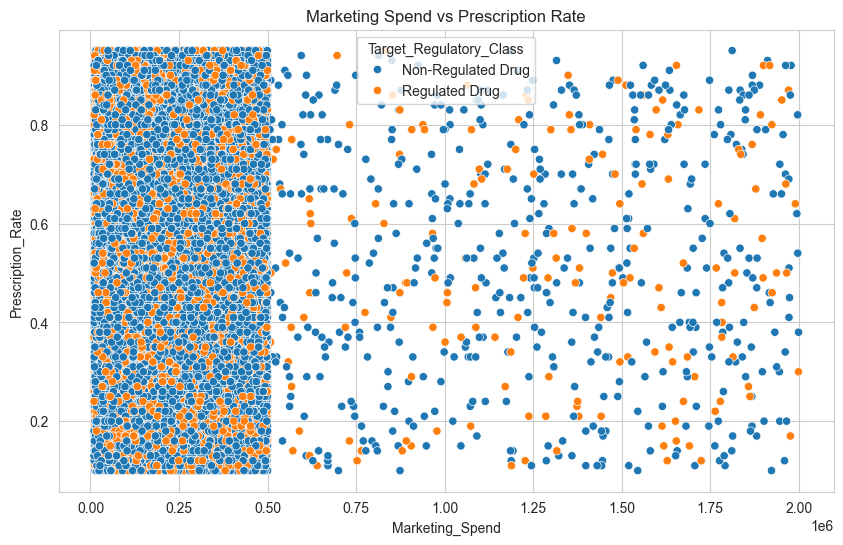

In [26]:
sns.scatterplot(x="Marketing_Spend", y="Prescription_Rate", hue="Target_Regulatory_Class", data=dataset)
plt.title("Marketing Spend vs Prescription Rate")
plt.show()

In [ ]:
#pair plot for multivariate relationships
sns.pairplot(dataset, hue = "Target_Regulatory_Class")
plt.show()

In [ ]:
#correlation heatmap for finding correlation
plt.figure(figsize=(14, 10))
corr = dataset[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="collwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#boxplot by target class
for col in num_cols:
    plt.figure()
    sns.boxplot(x = "Target_Regulatory_Class", y=col, data=dataset)
    plt.title(f"{col} Distribution by Target Class")
    plt.show()